Loaded 38 tickers


[**********************45%                       ]  17 of 38 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: MCG.JO"}}}
[*********************100%***********************]  38 of 38 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MCG.JO']: YFTzMissingError('possibly delisted; no timezone found')


Valid tickers: 37
Removed tickers: ['MCG.JO']


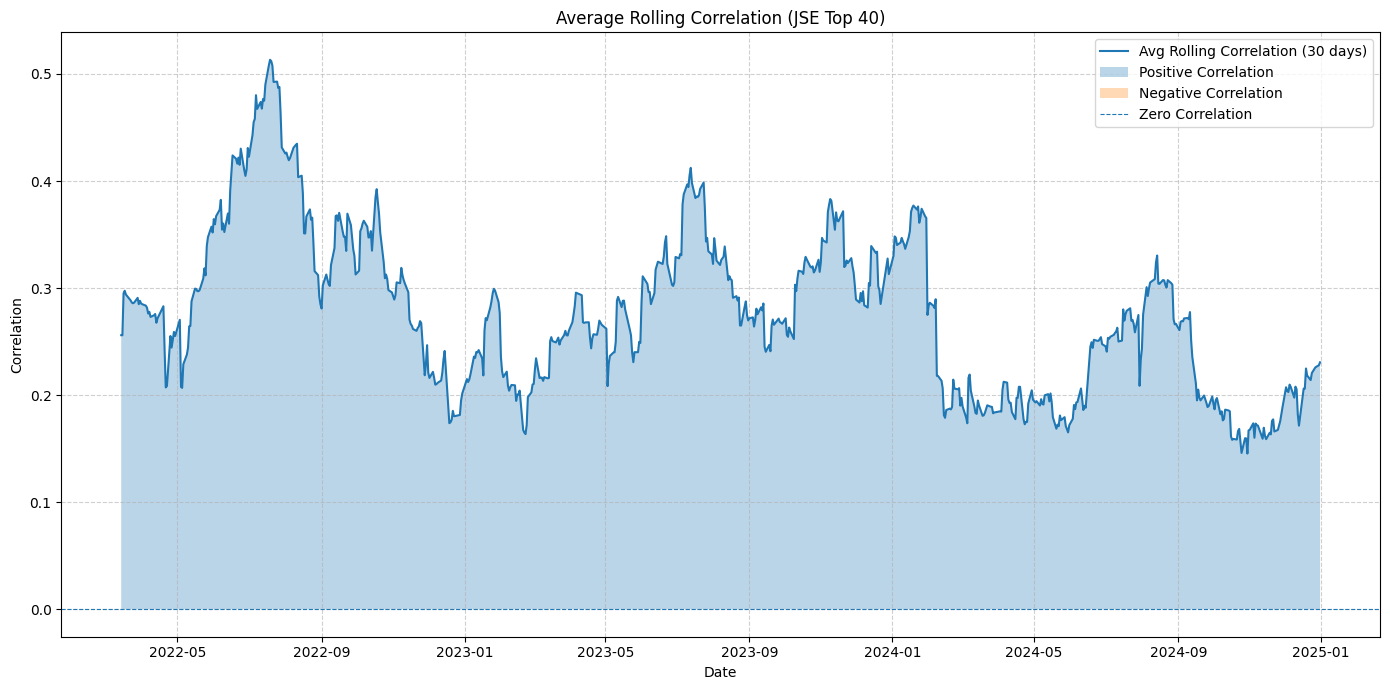

In [ ]:
# Install packages (only needed once)
!pip install yfinance matplotlib pandas numpy

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load tickers from your GitHub CSV
url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/refs/heads/main/Data/jse_top40_yfinance.csv"
df = pd.read_csv(url)

tickers = df["Ticker"].dropna().tolist()

# Optional: remove problematic tickers
tickers = [t for t in tickers if t != "RMH.JO"]

print(f"Loaded {len(tickers)} tickers")

# 2. Download historical data
start_date = "2015-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]

# Drop tickers that failed (all NaN columns)
data = data.dropna(axis=1, how='all')

# Show which tickers were removed
valid_tickers = data.columns.tolist()
removed = list(set(tickers) - set(valid_tickers))

print(f"Valid tickers: {len(valid_tickers)}")
print(f"Removed tickers: {removed}")

# 3. Calculate returns
#returns = data.pct_change().dropna()
returns = data.pct_change(fill_method=None).dropna()

# 4. Compute rolling correlation matrix (example: average correlation)
window = 30

rolling_corr = returns.rolling(window).corr()

# Example: average pairwise correlation over time
avg_corr = rolling_corr.groupby(level=0).mean().mean(axis=1)

# 5. Plot
plt.figure(figsize=(14, 7))
plt.plot(avg_corr.index, avg_corr, label=f'Avg Rolling Correlation ({window} days)')

plt.fill_between(avg_corr.index, avg_corr, 0,
                 where=avg_corr >= 0, alpha=0.3,
                 label='Positive Correlation')
plt.fill_between(avg_corr.index, avg_corr, 0,
                 where=avg_corr < 0, alpha=0.3,
                 label='Negative Correlation')

plt.axhline(0, linestyle='--', linewidth=0.8, label='Zero Correlation')

plt.title(f'Average Rolling Correlation (JSE Top 40)')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **US**


# **EU**

# **JAPAN**

In [ ]:
# Install yfinance if you haven't already
!pip install yfinance matplotlib pandas numpy

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

/tmp/ipykernel_4226/3672483690.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed


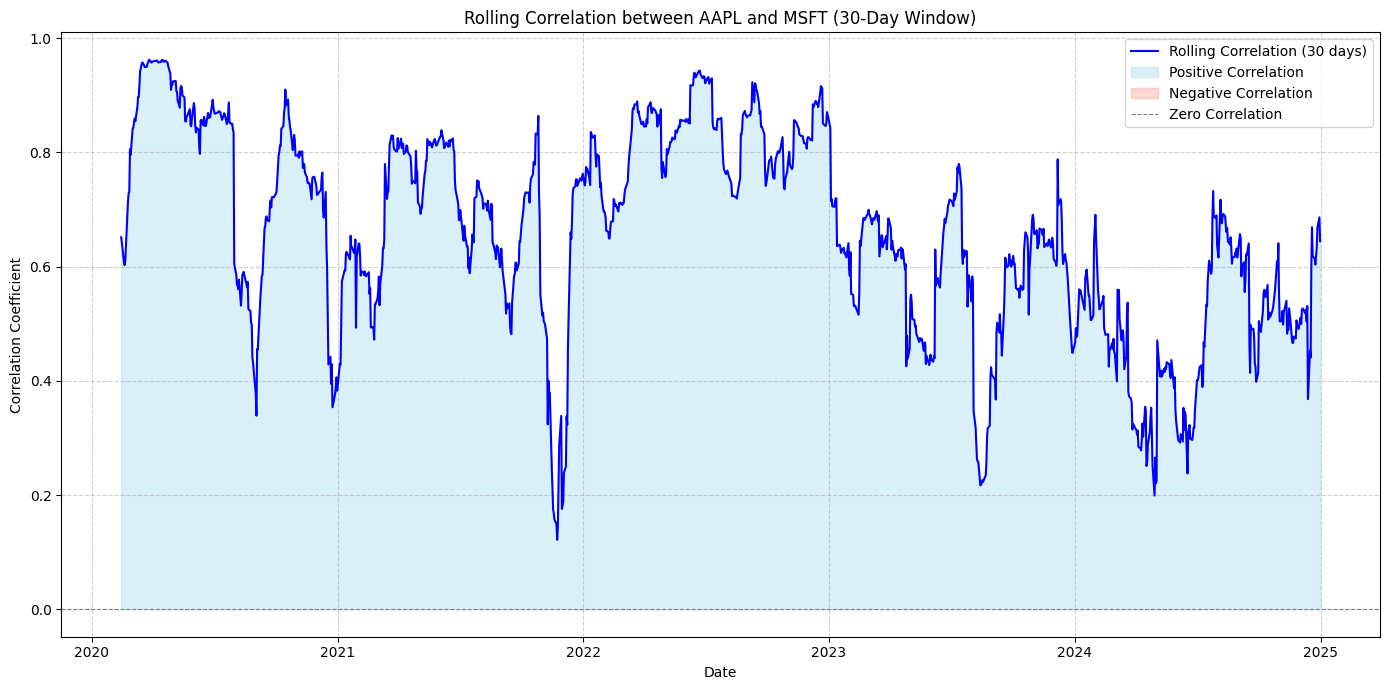

In [ ]:


# 1. Download historical stock data
tickers = ["AAPL", "MSFT"]
start_date = "2020-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date)

# We'll use the 'Adj Close' prices for our analysis
aapl_prices = data['Close']['AAPL']
msft_prices = data['Close']['MSFT']

# Calculate daily returns
aapl_returns = aapl_prices.pct_change().dropna()
msft_returns = msft_prices.pct_change().dropna()

# Align the indices after dropping NaNs
# This ensures both series have the same dates
common_index = aapl_returns.index.intersection(msft_returns.index)
aapl_returns = aapl_returns.loc[common_index]
msft_returns = msft_returns.loc[common_index]

# 2. Calculate rolling correlation
window = 30 # 30-day rolling window
rolling_correlation = aapl_returns.rolling(window=window).corr(msft_returns).dropna()

# 3. Plot the rolling correlation with fill_between
plt.figure(figsize=(14, 7))
plt.plot(rolling_correlation.index, rolling_correlation, label=f'Rolling Correlation ({window} days)', color='blue')

# Fill the area between the correlation and 0
# You can adjust the `y2` value to fill relative to a different baseline
plt.fill_between(rolling_correlation.index, rolling_correlation, 0,
                 where=rolling_correlation >= 0, color='skyblue', alpha=0.3,
                 label='Positive Correlation')
plt.fill_between(rolling_correlation.index, rolling_correlation, 0,
                 where=rolling_correlation < 0, color='salmon', alpha=0.3,
                 label='Negative Correlation')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='Zero Correlation') # Add a zero line

plt.title(f'Rolling Correlation between AAPL and MSFT ({window}-Day Window)')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()




/tmp/ipykernel_4226/3643536927.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed


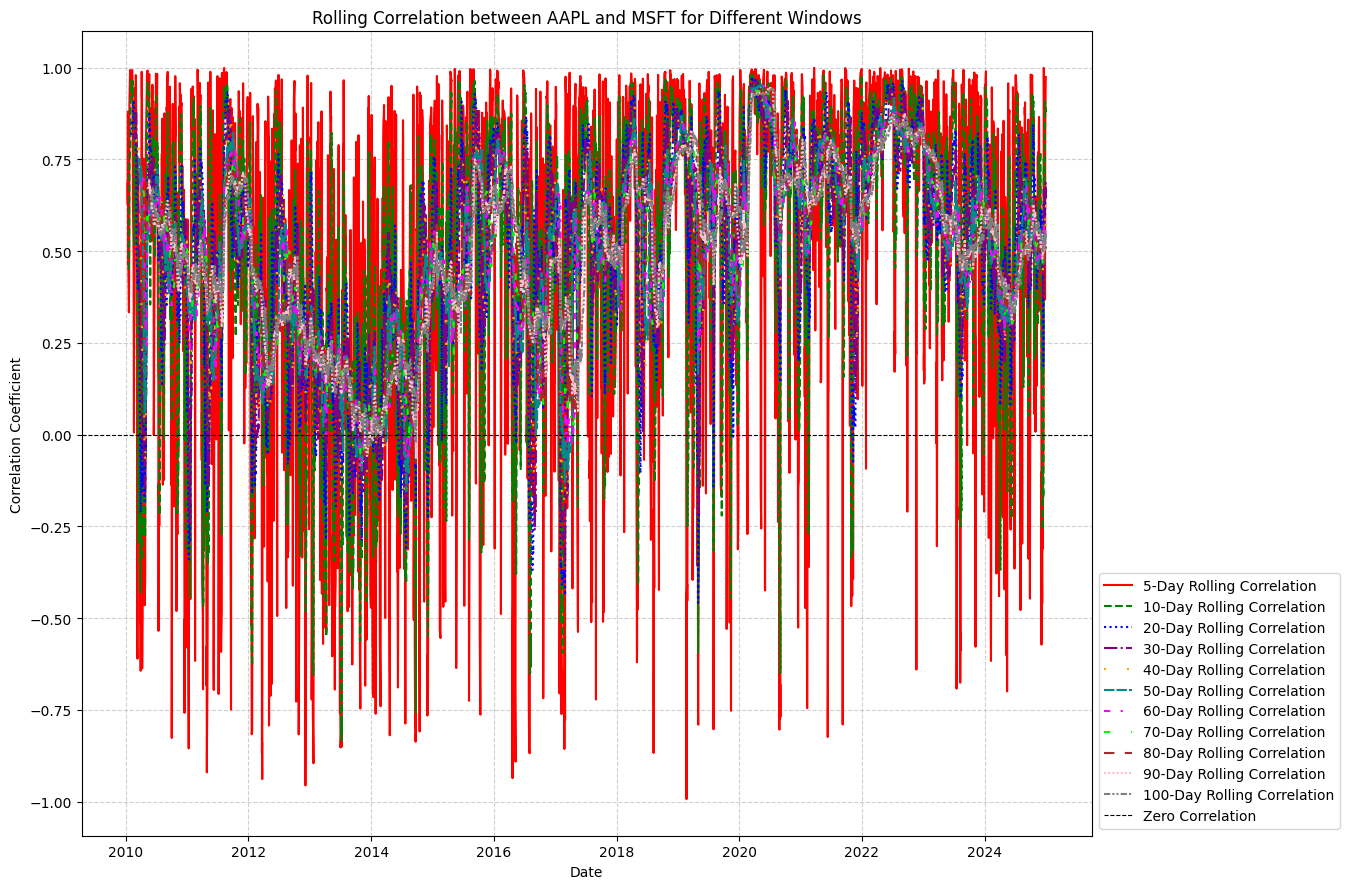

In [ ]:
# 1. Download historical stock data
tickers = ["AAPL", "MSFT"]
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date)

# We'll use the 'Adj Close' prices for our analysis for consistency
# The 'Close' price is fine too, but 'Adj Close' is generally preferred for historical analysis
aapl_prices = data['Close']['AAPL'] # Changed back to Adj Close
msft_prices = data['Close']['MSFT'] # Changed back to Adj Close

# Calculate daily returns
aapl_returns = aapl_prices.pct_change().dropna()
msft_returns = msft_prices.pct_change().dropna()

# Align the indices after dropping NaNs
# This ensures both series have the same dates
common_index = aapl_returns.index.intersection(msft_returns.index)
aapl_returns = aapl_returns.loc[common_index]
msft_returns = msft_returns.loc[common_index]

# Define the rolling windows you want to plot
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
rolling_correlations = {}

# 2. Calculate rolling correlations for each window
for window in windows:
    # A 1-day rolling correlation is essentially the correlation of daily returns without a rolling window
    # For a 1-day window, the correlation is typically just the correlation of the actual returns for that day
    # However, for consistency with rolling().corr(), we'll still use it, though it might be very noisy.
    # If you mean a simple daily correlation, it's just `aapl_returns.corr(msft_returns)` for each day's pair,
    # which is the same as window=1 for rolling.
    if window == 1: # This condition is now technically not met since 1 is not in your `windows` list
        current_corr = aapl_returns.rolling(window=window).corr(msft_returns)
    else:
        current_corr = aapl_returns.rolling(window=window).corr(msft_returns).dropna()
    rolling_correlations[window] = current_corr


# 3. Plot all rolling correlations on one graph
plt.figure(figsize=(16, 9)) # Increased figure size for better visibility with more lines

# Provide enough distinct colors and linestyles for all your windows
colors = [
    'red', 'green', 'blue', 'purple', 'orange',
    'darkcyan', 'magenta', 'lime', 'brown', 'pink',
    'gray', 'teal', 'navy', 'olive', 'gold' # Added more colors than needed, just in case
]
linestyles = [
    '-', '--', ':', '-.',
    (0, (1, 10)), # loosely dashed
    (0, (5, 1)),  # densely dashed
    (0, (3, 5, 1, 5)), # dashdotdot
    (0, (3, 10, 1, 10)), # long dash with space
    (0, (5, 5)), # dashed
    (0, (1, 1)), # dotted
    (0, (3, 1, 1, 1, 1, 1)) # complicated
]
# Ensure you have at least as many linestyles as windows,
# or loop them if you want to repeat patterns.
# For simplicity, let's just make sure we have enough.
# A simpler approach for linestyles if you have many lines is to cycle through a shorter list:
# from itertools import cycle
# line_cycler = cycle(['-', '--', ':', '-.', (0, (1, 10)), (0, (3, 5, 1, 5))])

for i, window in enumerate(windows):
    corr_series = rolling_correlations[window]
    # Use modulo operator to cycle through colors and linestyles if you don't have enough unique ones
    # This ensures no IndexError even if `windows` list grows very large without updating colors/linestyles
    plt.plot(corr_series.index, corr_series,
             label=f'{window}-Day Rolling Correlation',
             color=colors[i % len(colors)], # Use modulo to cycle colors
             linestyle=linestyles[i % len(linestyles)]) # Use modulo to cycle linestyles

plt.axhline(0, color='black', linestyle='--', linewidth=0.8, label='Zero Correlation') # Changed to black for better contrast

plt.title('Rolling Correlation between AAPL and MSFT for Different Windows')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0)) # Move legend outside to avoid obscuring lines
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend on the right
plt.show()

/tmp/ipykernel_4226/1961566236.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed


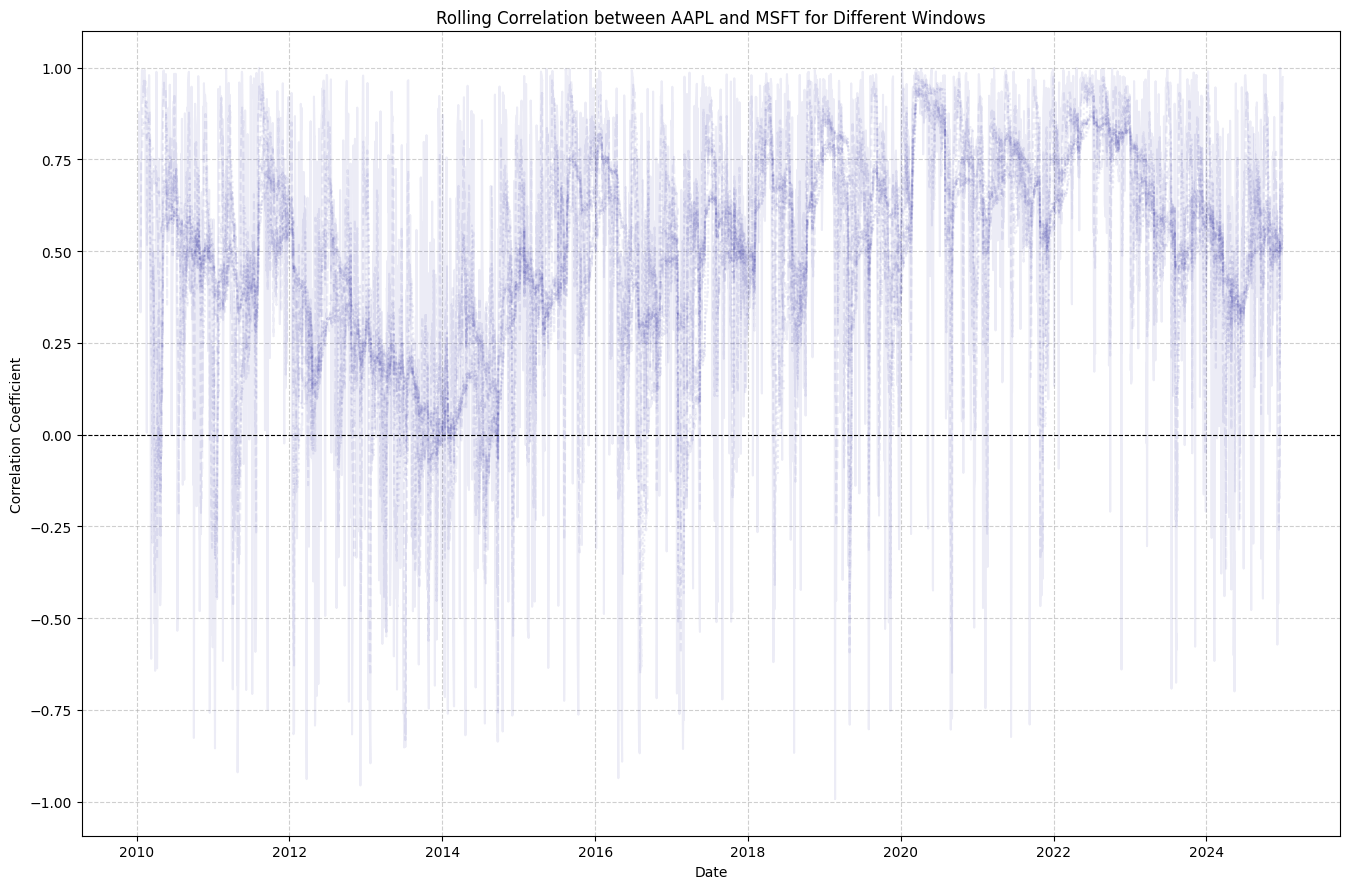

In [ ]:
# 1. Download historical stock data
tickers = ["AAPL", "MSFT"]
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date)

# We'll use the 'Adj Close' prices for our analysis for consistency
# The 'Close' price is fine too, but 'Adj Close' is generally preferred for historical analysis
aapl_prices = data['Close']['AAPL']
msft_prices = data['Close']['MSFT']

# Calculate daily returns
aapl_returns = aapl_prices.pct_change().dropna()
msft_returns = msft_prices.pct_change().dropna()

# Align the indices after dropping NaNs
# This ensures both series have the same dates
common_index = aapl_returns.index.intersection(msft_returns.index)
aapl_returns = aapl_returns.loc[common_index]
msft_returns = msft_returns.loc[common_index]

# Define the rolling windows you want to plot
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
rolling_correlations = {}

# 2. Calculate rolling correlations for each window
for window in windows:
    # A 1-day rolling correlation is essentially the correlation of daily returns without a rolling window
    # For a 1-day window, the correlation is typically just the correlation of the actual returns for that day
    # However, for consistency with rolling().corr(), we'll still use it, though it might be very noisy.
    # If you mean a simple daily correlation, it's just `aapl_returns.corr(msft_returns)` for each day's pair,
    # which is the same as window=1 for rolling.
    if window == 1: # This condition is now technically not met since 1 is not in your `windows` list
        current_corr = aapl_returns.rolling(window=window).corr(msft_returns)
    else:
        current_corr = aapl_returns.rolling(window=window).corr(msft_returns).dropna()
    rolling_correlations[window] = current_corr


# 3. Plot all rolling correlations on one graph
plt.figure(figsize=(16, 9)) # Increased figure size for better visibility with more lines

# --- Changes for plotting style ---
# Define a single color for all lines
plot_color = 'darkblue' # Or 'blue', 'gray', etc. Choose a color that works well with transparency.

# Calculate transparency based on the number of lines
num_windows = len(windows)
# A good starting point for alpha is 1 / num_windows, but we can adjust it
# to make them more visible if 1/N is too faint. Let's try a base of 0.8.
base_alpha = 0.8
line_alpha = base_alpha / num_windows

# Linestyles are still useful to differentiate lines even with the same color
linestyles = [
    '-', '--', ':', '-.',
    (0, (1, 10)), # loosely dashed
    (0, (5, 1)),  # densely dashed
    (0, (3, 5, 1, 5)), # dashdotdot
    (0, (3, 10, 1, 10)), # long dash with space
    (0, (5, 5)), # dashed
    (0, (1, 1)), # dotted
    (0, (3, 1, 1, 1, 1, 1)) # complicated
]
# --- End of changes for plotting style ---

for i, window in enumerate(windows):
    corr_series = rolling_correlations[window]
    plt.plot(corr_series.index, corr_series,
             label=f'{window}-Day Rolling Correlation',
             color=plot_color, # Use the single defined color
             linestyle=linestyles[i % len(linestyles)], # Cycle linestyles
             alpha=line_alpha) # Apply calculated transparency

plt.axhline(0, color='black', linestyle='--', linewidth=0.8, label='Zero Correlation')

plt.title('Rolling Correlation between AAPL and MSFT for Different Windows')
plt.xlabel('Date')
plt.ylabel('Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(loc='lower left', bbox_to_anchor=(1, 0))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/tmp/ipykernel_4226/1189406403.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed


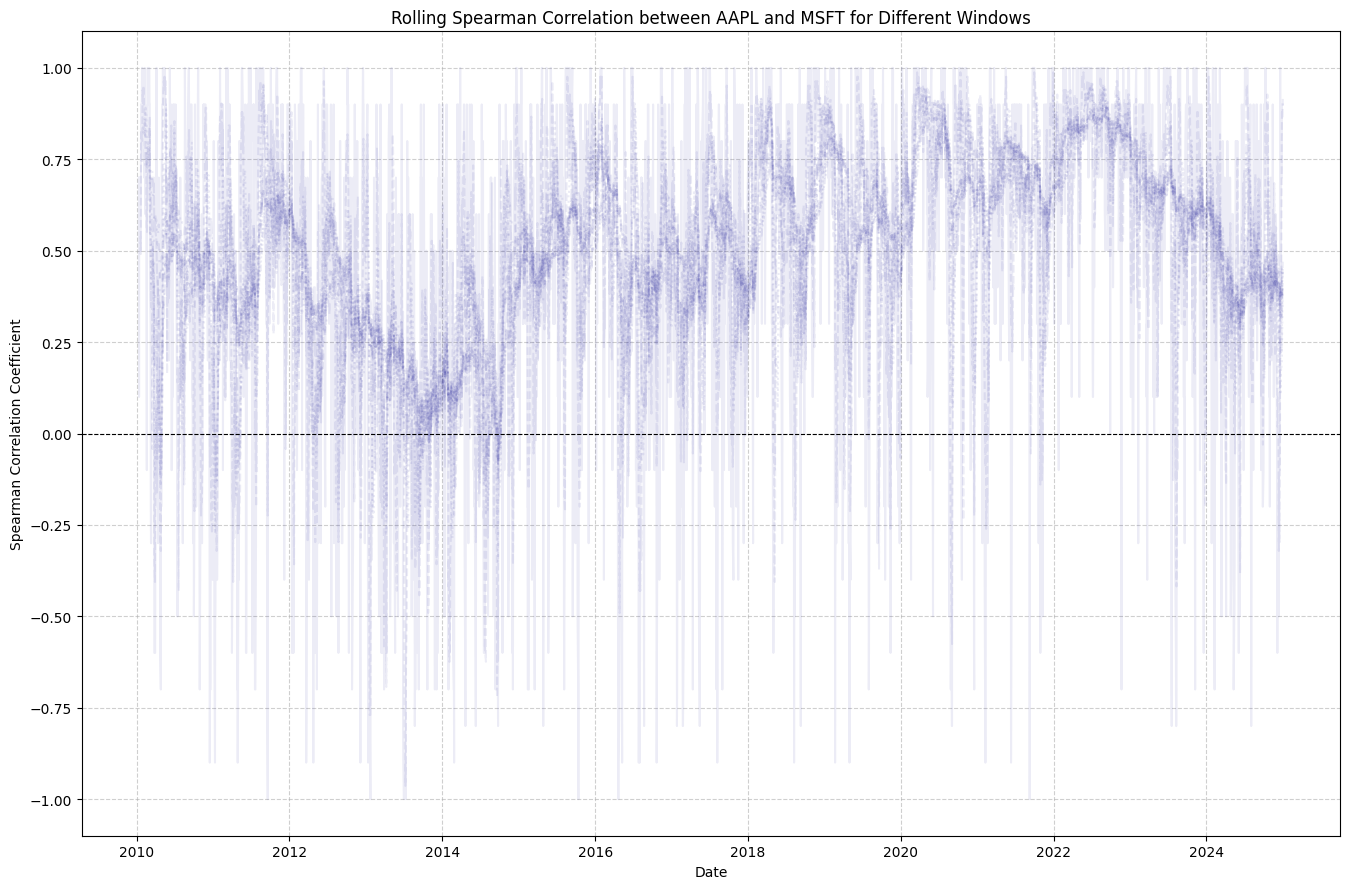

In [ ]:
# Install yfinance if you haven't already
!pip install yfinance matplotlib pandas numpy scipy # Ensure scipy is installed

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr # Import spearmanr from scipy.stats

# 1. Download historical stock data
tickers = ["AAPL", "MSFT"]
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(tickers, start=start_date, end=end_date)

# We'll use the 'Adj Close' prices for our analysis for consistency
# 'Adj Close' is generally preferred for historical analysis as it accounts for splits and dividends.
aapl_prices = data['Close']['AAPL']
msft_prices = data['Close']['MSFT']

# Calculate daily returns
aapl_returns = aapl_prices.pct_change().dropna()
msft_returns = msft_prices.pct_change().dropna()

# Align the indices after dropping NaNs
# This ensures both series have the same dates
common_index = aapl_returns.index.intersection(msft_returns.index)
aapl_returns = aapl_returns.loc[common_index]
msft_returns = msft_returns.loc[common_index]

# Define the rolling windows you want to plot
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
rolling_correlations = {}

# 2. Calculate rolling Spearman correlations for each window
for window in windows:
    # Use rolling().apply() with a custom function to calculate Spearman correlation
    # The lambda function receives the 'aapl_returns' window as 'x'.
    # We then align 'msft_returns' to the same index 'x.index' for the correlation calculation.
    # spearmanr returns a tuple (correlation_coefficient, p_value), so we take the [0] element.
    # raw=False ensures that 'x' is a pandas Series, allowing for .loc[x.index]
    current_corr = aapl_returns.rolling(window=window).apply(
        lambda x: spearmanr(x, msft_returns.loc[x.index])[0],
        raw=False
    ).dropna()
    rolling_correlations[window] = current_corr

# 3. Plot all rolling correlations on one graph
plt.figure(figsize=(16, 9))

# Define a single color for all lines
plot_color = 'darkblue'

# Calculate transparency based on the number of lines
num_windows = len(windows)
base_alpha = 0.8
line_alpha = base_alpha / num_windows

# Linestyles are still useful to differentiate lines even with the same color
linestyles = [
    '-', '--', ':', '-.',
    (0, (1, 10)),
    (0, (5, 1)),
    (0, (3, 5, 1, 5)),
    (0, (3, 10, 1, 10)),
    (0, (5, 5)),
    (0, (1, 1)),
    (0, (3, 1, 1, 1, 1, 1))
]

for i, window in enumerate(windows):
    corr_series = rolling_correlations[window]
    plt.plot(corr_series.index, corr_series,
             label=f'{window}-Day Rolling Spearman Correlation',
             color=plot_color,
             linestyle=linestyles[i % len(linestyles)],
             alpha=line_alpha)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8, label='Zero Correlation')

plt.title('Rolling Spearman Correlation between AAPL and MSFT for Different Windows')
plt.xlabel('Date')
plt.ylabel('Spearman Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
#plt.legend(loc='lower left', bbox_to_anchor=(1, 0))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/tmp/ipykernel_4226/2755410854.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[                       0%                       ]

[*********************100%***********************]  2 of 2 completed


Data download complete.
Calculating rolling Spearman correlations...
  - 5-Day correlation calculated. Data points: 3769
  - 10-Day correlation calculated. Data points: 3764
  - 20-Day correlation calculated. Data points: 3754
  - 30-Day correlation calculated. Data points: 3744
  - 40-Day correlation calculated. Data points: 3734
  - 50-Day correlation calculated. Data points: 3724
  - 60-Day correlation calculated. Data points: 3714
  - 70-Day correlation calculated. Data points: 3704
  - 80-Day correlation calculated. Data points: 3694
  - 90-Day correlation calculated. Data points: 3684
  - 100-Day correlation calculated. Data points: 3674
Correlation calculations complete.


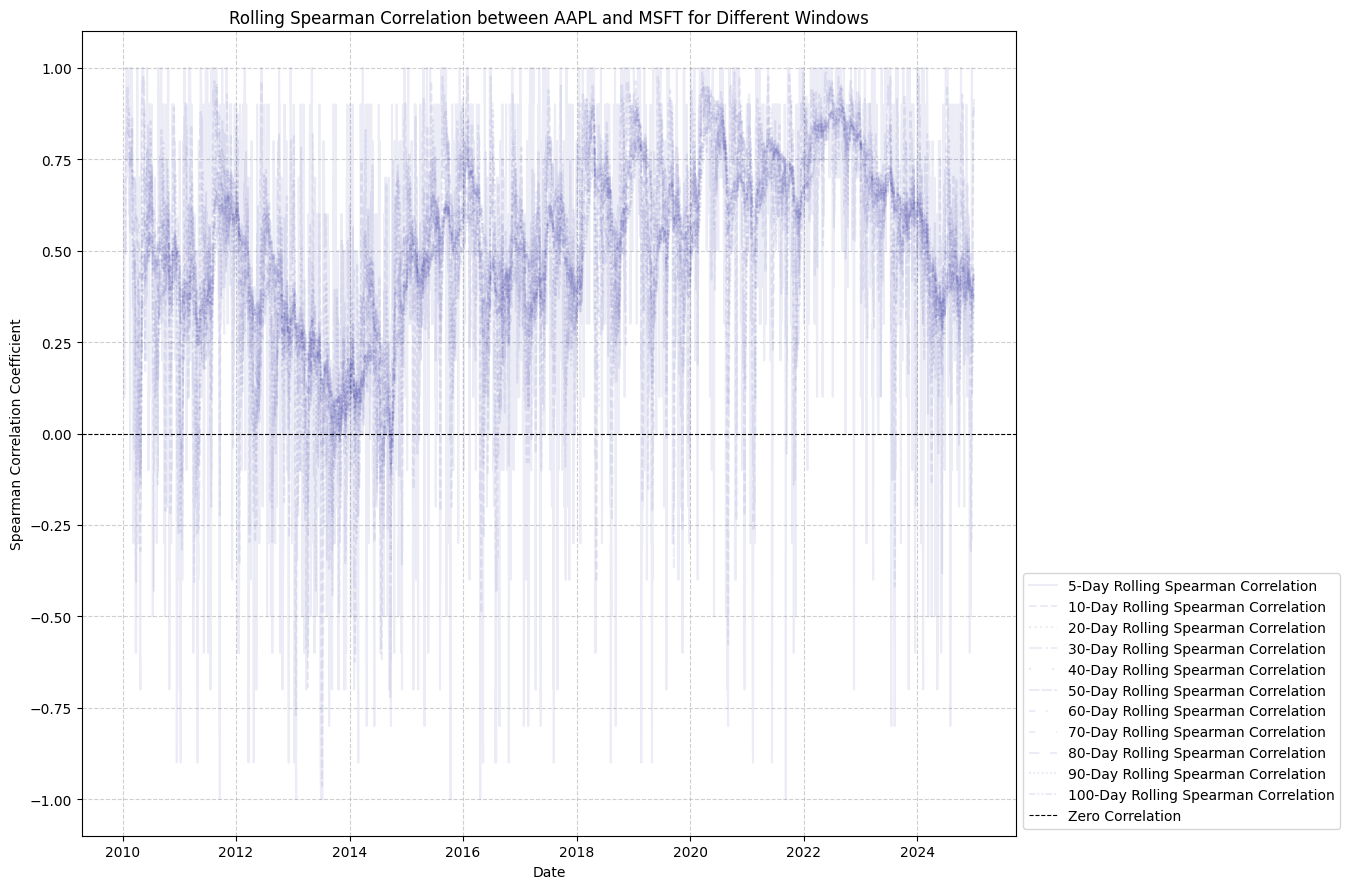


Generating histogram of all correlation values...


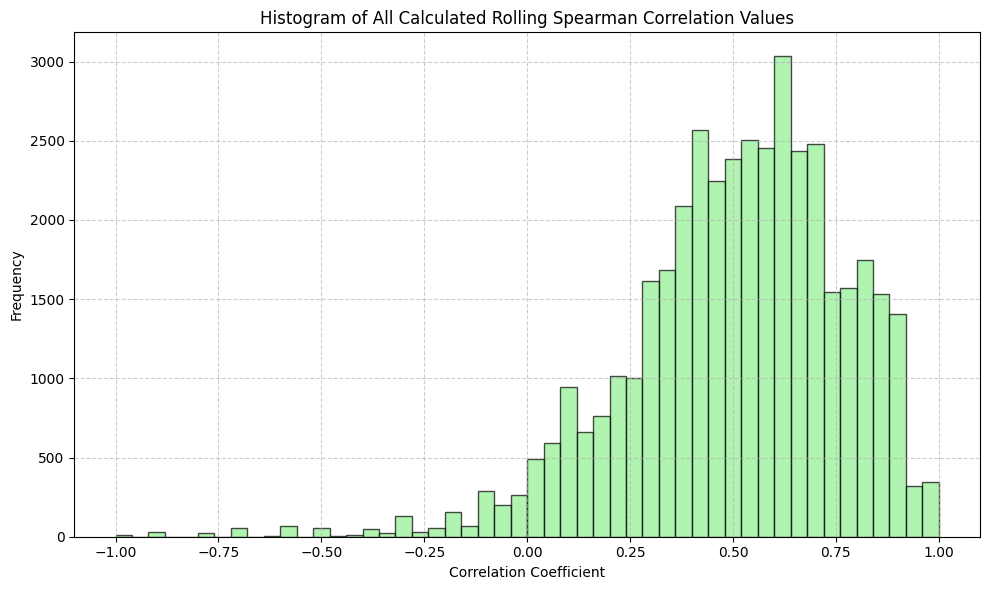

Histogram generated.


In [ ]:
# 1. Download historical stock data
tickers = ["AAPL", "MSFT"]
start_date = "2010-01-01"
end_date = "2025-01-01"

print(f"Downloading data for {tickers} from {start_date} to {end_date}...")
data = yf.download(tickers, start=start_date, end=end_date)
print("Data download complete.")

# We'll use the 'Adj Close' prices for our analysis for consistency
# 'Adj Close' is generally preferred for historical analysis as it accounts for splits and dividends.
aapl_prices = data['Close']['AAPL']
msft_prices = data['Close']['MSFT']

# Calculate daily returns
aapl_returns = aapl_prices.pct_change().dropna()
msft_returns = msft_prices.pct_change().dropna()

# Align the indices after dropping NaNs
# This ensures both series have the same dates
common_index = aapl_returns.index.intersection(msft_returns.index)
aapl_returns = aapl_returns.loc[common_index]
msft_returns = msft_returns.loc[common_index]

# Define the rolling windows you want to plot
windows = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
rolling_correlations = {}

# 2. Calculate rolling Spearman correlations for each window
print("Calculating rolling Spearman correlations...")
for window in windows:
    current_corr = aapl_returns.rolling(window=window).apply(
        lambda x: spearmanr(x, msft_returns.loc[x.index])[0],
        raw=False
    ).dropna()
    rolling_correlations[window] = current_corr
    print(f"  - {window}-Day correlation calculated. Data points: {len(current_corr)}")
print("Correlation calculations complete.")


# 3. Plot all rolling correlations on one graph (Time Series Plot)
plt.figure(figsize=(16, 9))

# Define a single color for all lines
plot_color = 'darkblue'

# Calculate transparency based on the number of lines
num_windows = len(windows)
base_alpha = 0.8
line_alpha = base_alpha / num_windows

# Linestyles are still useful to differentiate lines even with the same color
linestyles = [
    '-', '--', ':', '-.',
    (0, (1, 10)),
    (0, (5, 1)),
    (0, (3, 5, 1, 5)),
    (0, (3, 10, 1, 10)),
    (0, (5, 5)),
    (0, (1, 1)),
    (0, (3, 1, 1, 1, 1, 1))
]

for i, window in enumerate(windows):
    corr_series = rolling_correlations[window]
    plt.plot(corr_series.index, corr_series,
             label=f'{window}-Day Rolling Spearman Correlation',
             color=plot_color,
             linestyle=linestyles[i % len(linestyles)],
             alpha=line_alpha)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8, label='Zero Correlation')

plt.title('Rolling Spearman Correlation between AAPL and MSFT for Different Windows')
plt.xlabel('Date')
plt.ylabel('Spearman Correlation Coefficient')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', bbox_to_anchor=(1, 0))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# 4. Create a Histogram of all calculated correlation values
print("\nGenerating histogram of all correlation values...")
all_correlation_values = []
for window in windows:
    # Use .tolist() to get the values from the Series and extend the list
    all_correlation_values.extend(rolling_correlations[window].tolist())

# Convert to a NumPy array for histogram plotting
all_correlation_values_np = np.array(all_correlation_values)

plt.figure(figsize=(10, 6)) # New figure for the histogram
# A typical range for correlation is -1 to 1. Using bins=50 is a good start.
plt.hist(all_correlation_values_np, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')

plt.title('Histogram of All Calculated Rolling Spearman Correlation Values')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
print("Histogram generated.")

Fetched 503 tickers


[                       0%                       ]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks


/tmp/ipykernel_4226/3177289549.py:30: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


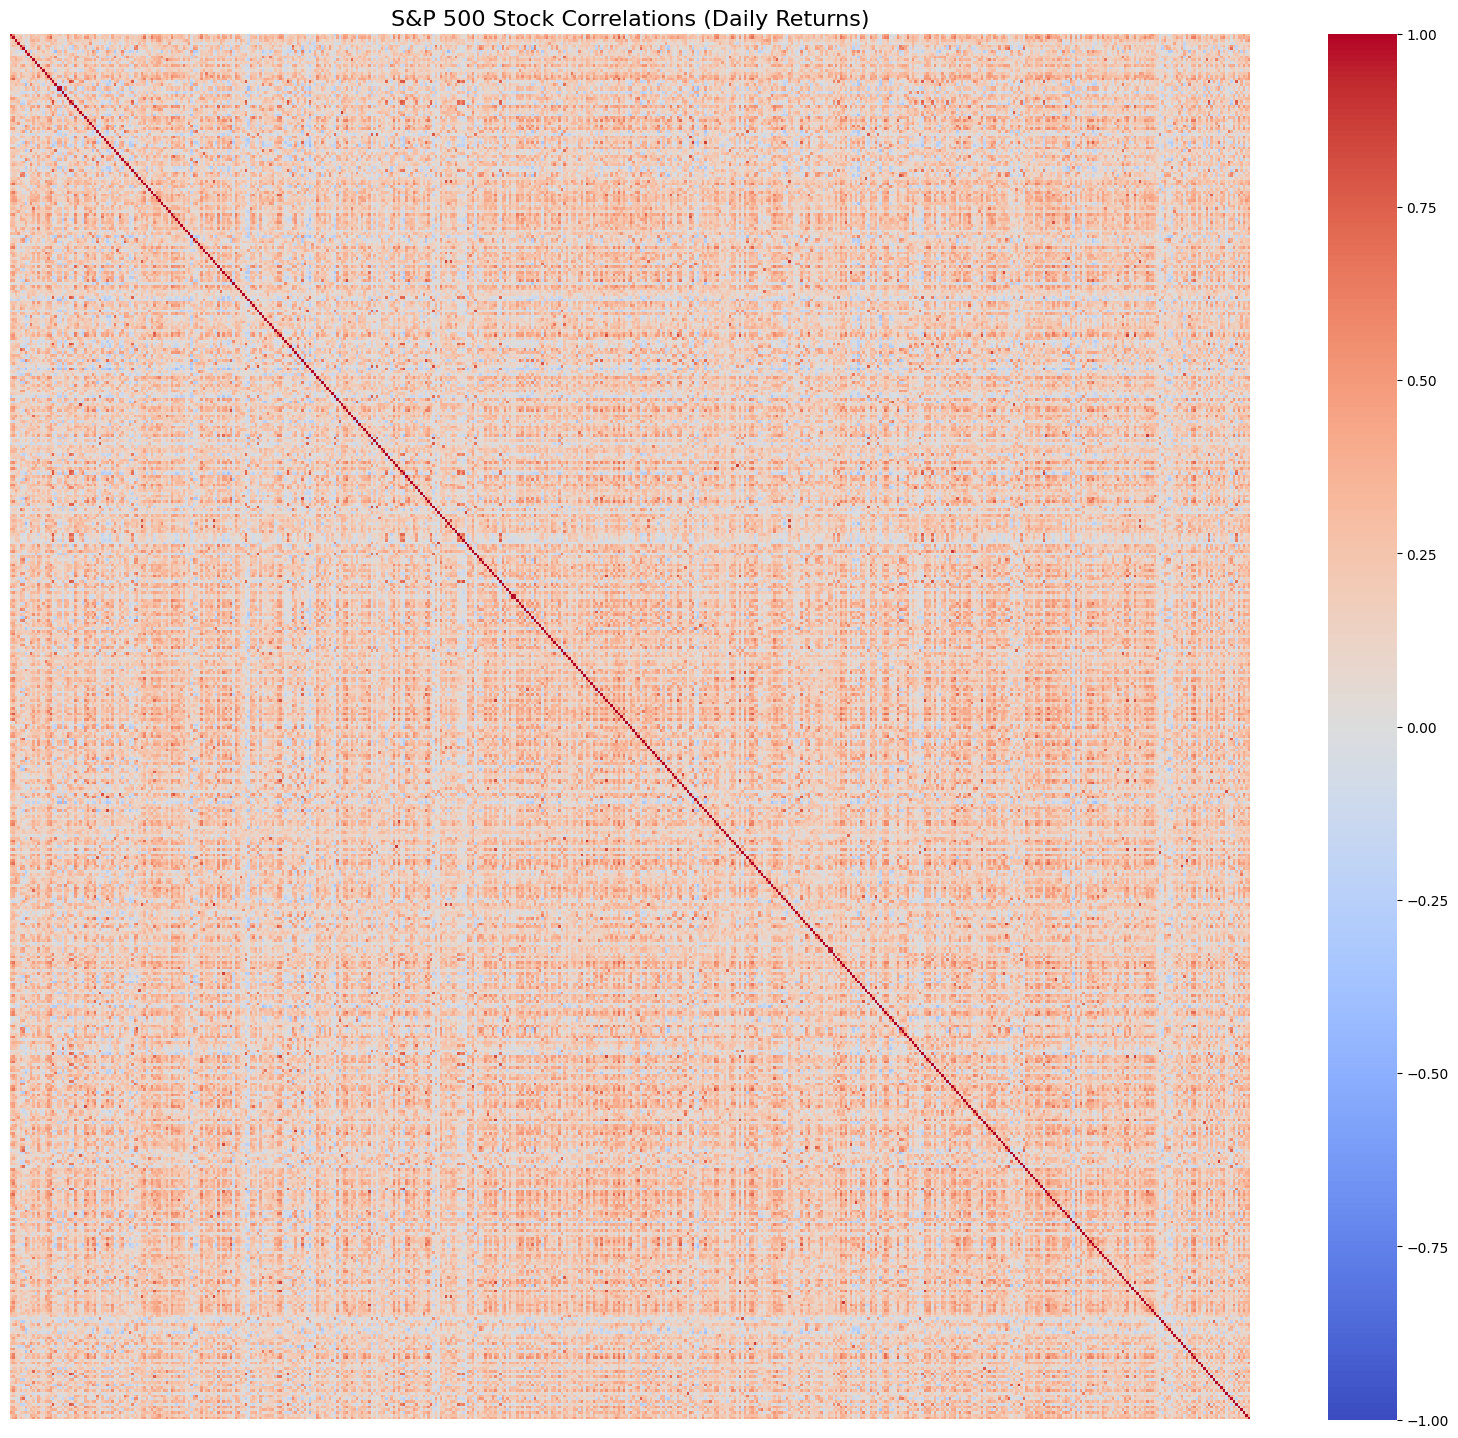

In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV"""
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    df = pd.read_csv(raw_url)
    tickers = df['Symbol'].tolist()
    return [t.replace('.', '-') for t in tickers]  # Clean symbols for yfinance


def download_historical_data(tickers, start_date='2013-01-01'):
    """Download historical stock data for all S&P 500 components"""
    data = yf.download(
        tickers,
        start=start_date,
        end=datetime.today().strftime('%Y-%m-%d'),
        group_by='ticker',
        auto_adjust=True  # Use only adjusted prices
    )
    # Extract closing prices and clean data
    closes = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers})
    return closes.dropna(axis=1, how='all')  # Drop columns with all NaNs

def calculate_correlations(prices, method='spearman'):
    """Calculate correlation matrix for daily returns"""
    returns = prices.pct_change().dropna()
    return returns.corr(method=method)

def plot_correlation_heatmap(corr_matrix):
    """Visualize the correlation matrix as a heatmap"""
    plt.figure(figsize=(20, 18))
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        xticklabels=False,
        yticklabels=False
    )
    plt.title('S&P 500 Stock Correlations (Daily Returns)', fontsize=16)
    plt.show()

def rolling_correlation(returns, ticker1, ticker2, window=63):
    """Calculate rolling correlation between two stocks"""
    pair_returns = returns[[ticker1, ticker2]].dropna()
    rolling_corr = pair_returns[ticker1].rolling(window).corr(pair_returns[ticker2])
    return rolling_corr.dropna()

def plot_rolling_correlation(rolling_corr):
    """Plot rolling correlation and histogram"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Time series plot
    rolling_corr.plot(ax=ax1, title=f'{rolling_corr.name} Rolling Correlation')
    ax1.axhline(0, color='black', linestyle='--')
    ax1.set_ylabel('Correlation')

    # Histogram
    sns.histplot(rolling_corr, ax=ax2, kde=True, bins=30)
    ax2.set_xlabel('Correlation')
    ax2.set_title('Distribution of Rolling Correlation Values')
    ax2.set_xlim(-1, 1)

    plt.tight_layout()
    plt.show()

# Main execution flow
if __name__ == "__main__":
    # Fetch data
    tickers = fetch_sp500_tickers()
    print(f"Fetched {len(tickers)} tickers")

    # Download historical prices (this may take a few minutes)
    prices = download_historical_data(tickers[:], start_date='2013-01-01')  # Use [:] for all components
    print(f"Downloaded data for {prices.shape[1]} stocks")

    # Calculate correlations
    corr_matrix = calculate_correlations(prices)

    # Plot full correlation matrix
    plot_correlation_heatmap(corr_matrix)



/tmp/ipykernel_4226/3177289549.py:30: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()
/tmp/ipykernel_4226/655691565.py:53: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()  # Need returns for T calculation
/tmp/ipykernel_4226/655691565.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


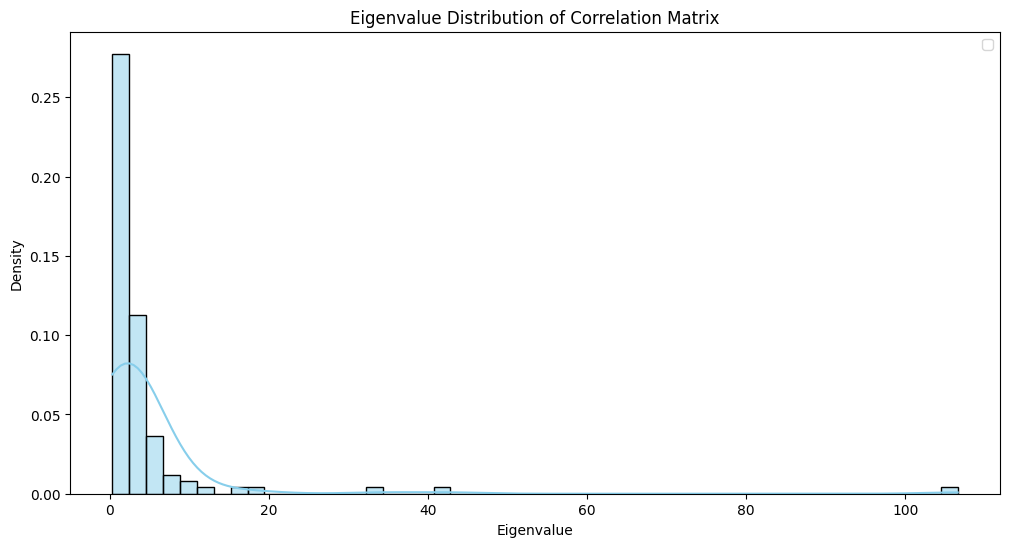

Eigenvalue analysis:
- Largest eigenvalue: 106.58
- Smallest eigenvalue: 0.30
- Condition number: 355.2


In [ ]:
import numpy as np  # Add this import at the top

# Add this new function
def plot_eigenvalue_distribution(corr_matrix):
    """Calculate and plot the eigenvalue distribution of the correlation matrix"""
    # Calculate eigenvalues
    eigenvalues = np.linalg.eigh(corr_matrix)[0]

    # Filter out near-zero eigenvalues (for numerical stability)
    eigenvalues = eigenvalues[eigenvalues > 1e-5]

    plt.figure(figsize=(12, 6))

    # Plot histogram with KDE
    sns.histplot(eigenvalues, bins=50, kde=True, stat='density', color='skyblue')

    # Calculate Marčenko-Pastur distribution parameters (optional theoretical comparison)
    N = corr_matrix.shape[0]  # Number of stocks
    T = len(returns)          # Number of time periods (daily returns)
    Q = N/T                   # Ratio of dimensions

    if Q < 1:
        # Theoretical bounds for random matrix eigenvalues
        lambda_plus = (1 + np.sqrt(Q))**2
        lambda_minus = (1 - np.sqrt(Q))**2

        # Plot theoretical distribution bounds
        plt.axvline(lambda_plus, color='red', linestyle='--',
                   label=f'Theoretical Max (λ+={lambda_plus:.2f})')
        plt.axvline(lambda_minus, color='green', linestyle='--',
                   label=f'Theoretical Min (λ-={lambda_minus:.2f})')

    plt.title('Eigenvalue Distribution of Correlation Matrix')
    plt.xlabel('Eigenvalue')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    # Print summary statistics
    print(f"Eigenvalue analysis:\n"
          f"- Largest eigenvalue: {np.max(eigenvalues):.2f}\n"
          f"- Smallest eigenvalue: {np.min(eigenvalues):.2f}\n"
          f"- Condition number: {np.max(eigenvalues)/np.min(eigenvalues):.1f}")

# Modify the main execution flow to include eigenvalue analysis
if __name__ == "__main__":
    # ... [previous code until correlation matrix calculation] ...

    # Calculate correlations
    corr_matrix = calculate_correlations(prices)

    # Plot eigenvalue distribution (ADD THIS RIGHT BEFORE HEATMAP)
    returns = prices.pct_change().dropna()  # Need returns for T calculation
    plot_eigenvalue_distribution(corr_matrix)



/tmp/ipykernel_4226/3177289549.py:30: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()
/tmp/ipykernel_4226/2850847576.py:53: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()  # Need returns for T calculation
/tmp/ipykernel_4226/2850847576.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


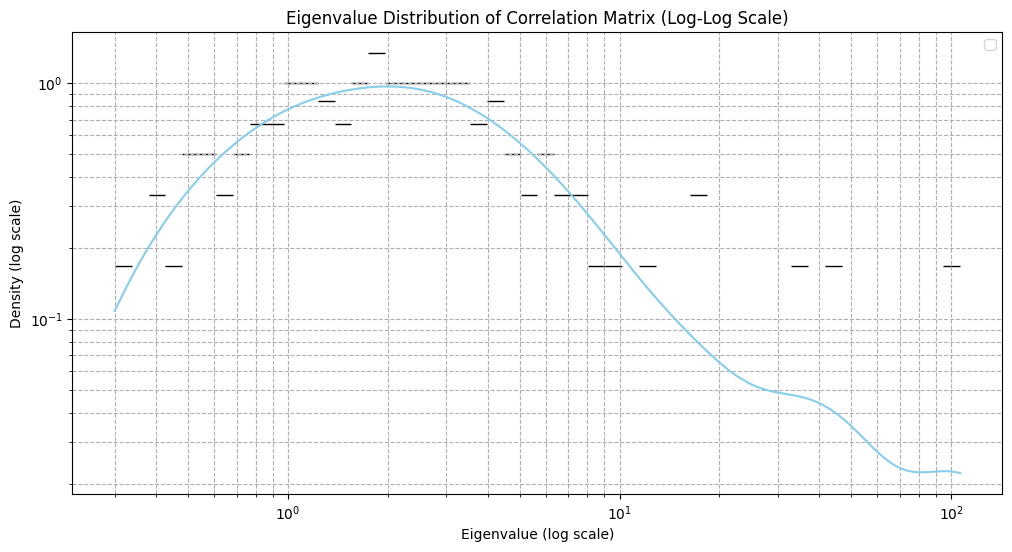

Eigenvalue analysis:
- Largest eigenvalue: 106.58
- Smallest eigenvalue: 0.30
- Condition number: 355.2


In [ ]:
def plot_eigenvalue_distribution(corr_matrix):
    """Calculate and plot the eigenvalue distribution of the correlation matrix"""
    # Calculate eigenvalues
    eigenvalues = np.linalg.eigh(corr_matrix)[0]

    # Filter out near-zero eigenvalues (for numerical stability)
    eigenvalues = eigenvalues[eigenvalues > 1e-5]

    plt.figure(figsize=(12, 6))

    # Plot histogram with KDE on logarithmic scales
    sns.histplot(eigenvalues, bins=50, kde=True, stat='density', color='skyblue',
                 log_scale=(True, True))  # This enables log scaling on both axes

    # Calculate Marčenko-Pastur distribution parameters
    N = corr_matrix.shape[0]  # Number of stocks
    T = len(returns)          # Number of time periods (daily returns)
    Q = N/T                   # Ratio of dimensions

    if Q < 1:
        # Theoretical bounds for random matrix eigenvalues
        lambda_plus = (1 + np.sqrt(Q))**2
        lambda_minus = (1 - np.sqrt(Q))**2

        # Plot theoretical distribution bounds
        plt.axvline(lambda_plus, color='red', linestyle='--',
                   label=f'Theoretical Max (λ+={lambda_plus:.2f})')
        plt.axvline(lambda_minus, color='green', linestyle='--',
                   label=f'Theoretical Min (λ-={lambda_minus:.2f})')

    plt.title('Eigenvalue Distribution of Correlation Matrix (Log-Log Scale)')
    plt.xlabel('Eigenvalue (log scale)')
    plt.ylabel('Density (log scale)')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

    # Print summary statistics
    print(f"Eigenvalue analysis:\n"
          f"- Largest eigenvalue: {np.max(eigenvalues):.2f}\n"
          f"- Smallest eigenvalue: {np.min(eigenvalues):.2f}\n"
          f"- Condition number: {np.max(eigenvalues)/np.min(eigenvalues):.1f}")


# Modify the main execution flow to include eigenvalue analysis
if __name__ == "__main__":
    # ... [previous code until correlation matrix calculation] ...

    # Calculate correlations
    corr_matrix = calculate_correlations(prices)

    # Plot eigenvalue distribution (ADD THIS RIGHT BEFORE HEATMAP)
    returns = prices.pct_change().dropna()  # Need returns for T calculation
    plot_eigenvalue_distribution(corr_matrix)




In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
from scipy.stats import spearmanr # Keep this for robustness if needed, though .corr() handles it

# --- Configuration for the animation ---
ANIMATION_WINDOW_SIZE = 63  # e.g., 63 trading days (~3 months)
ANIMATION_STEP_SIZE = 21   # e.g., 21 trading days (~1 month) per frame
OUTPUT_FOLDER = 'correlation_heatmap_frames'
IMAGE_DPI = 150 # Dots per inch for saved images (higher = better quality, larger files)
# --- End Configuration ---

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV (reliable source)"""
    # Using a known reliable public GitHub CSV for S&P 500 tickers
    # https://github.com/fja05680/sp500/blob/master/sp500.csv
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    try:
        df = pd.read_csv(raw_url)
        tickers = df['Symbol'].tolist()
        # Clean symbols for yfinance (e.g., BRK.B -> BRK-B)
        tickers = [t.replace('.', '-') for t in tickers]
        # Filter out problematic tickers if necessary (e.g., BRK-B can be large/slow)
        # tickers = [t for t in tickers if t not in ['BRK-B']]
        return tickers
    except Exception as e:
        print(f"Error fetching S&P 500 tickers from GitHub: {e}")
        print("Falling back to a small, hardcoded list.")
        return ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'] # Fallback list

def download_historical_data(tickers, start_date='2013-01-01'):
    """Download historical stock data for all S&P 500 components"""
    end_date = datetime.today().strftime('%Y-%m-%d')
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")

    # Use auto_adjust=True to automatically get adjusted closing prices
    # group_by='ticker' will structure the DataFrame with tickers as top-level columns
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=True,
        progress=False # Suppress progress bar for cleaner output
    )

    # If only one ticker is downloaded, data structure is different
    if isinstance(data.columns, pd.MultiIndex):
        closes = data.xs('Close', axis=1, level=1)
    else: # Case for single ticker download
        closes = data['Close'].to_frame() # Convert Series to DataFrame

    # Drop any columns (tickers) that have no data at all
    closes = closes.dropna(axis=1, how='all')
    print(f"Downloaded data for {closes.shape[1]} stocks with {len(closes)} dates.")
    return closes

def calculate_rolling_correlation_matrices(prices_df, window_size, step_size, method='spearman'):
    """
    Calculates rolling correlation matrices for daily returns.
    Returns a list of (end_date, correlation_matrix) tuples.
    """
    returns = prices_df.pct_change()

    # Drop columns (tickers) that are entirely NaN after pct_change
    # This ensures we only work with tickers that have some data
    returns = returns.dropna(axis=1, how='all')

    if len(returns) < window_size:
        print(f"Warning: Not enough data ({len(returns)} days) for window size {window_size}. Skipping rolling correlation matrices.")
        return []

    rolling_matrices = []
    print(f"Calculating rolling {method} correlation matrices (Window: {window_size} days, Step: {step_size} days)...")

    # Iterate through the returns DataFrame to define rolling windows
    # The loop starts from the first possible end date of a full window
    for i in range(window_size - 1, len(returns), step_size):
        window_end_date = returns.index[i]
        window_start_date = returns.index[i - window_size + 1]

        # Select the data for the current window
        window_returns = returns.loc[window_start_date:window_end_date]

        # Drop tickers that have no data within this specific window to avoid NaN matrices
        window_returns = window_returns.dropna(axis=1, how='all')

        # Only calculate if there are at least two valid stocks and enough data points in the window
        if window_returns.shape[1] >= 2 and len(window_returns) >= window_size:
            # Calculate correlation matrix for the current window
            corr_matrix = window_returns.corr(method=method)

            # Check if the calculated matrix itself is full of NaNs (e.g., all constant returns in window)
            if not corr_matrix.isnull().all().all():
                rolling_matrices.append((window_end_date, corr_matrix))
            else:
                print(f"  Skipping frame for {window_end_date.strftime('%Y-%m-%d')} due to NaN correlation matrix.")
        # else:
        #     print(f"  Skipping frame for {window_end_date.strftime('%Y-%m-%d')} due to insufficient valid data.")

    print(f"Calculated {len(rolling_matrices)} rolling correlation matrices.")
    return rolling_matrices

def plot_and_save_heatmap(corr_matrix, current_date, frame_num, output_folder, dpi):
    """
    Plots a single correlation heatmap and saves it as a PNG image.
    Hides ticker labels for clarity in animation.
    """
    plt.figure(figsize=(12, 10)) # Smaller figure size for animation frames
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1, # Ensure consistent color scale
        vmax=1, # Ensure consistent color scale
        annot=False,
        xticklabels=False, # Hide labels to prevent clutter
        yticklabels=False, # Hide labels to prevent clutter
        cbar_kws={'label': 'Correlation Coefficient'} # Add color bar label
    )
    plt.title(f'S&P 500 Rolling Correlation ({current_date.strftime("%Y-%m-%d")})', fontsize=16)

    # Save the figure
    filename = os.path.join(output_folder, f'heatmap_frame_{frame_num:04d}.png')
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close() # Close the plot to free up memory

# --- Main execution flow ---
if __name__ == "__main__":
    # Create output folder for animation frames
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # 1. Fetch S&P 500 tickers
    tickers = fetch_sp500_tickers()

    # 2. Download historical prices
    # Ensure start_date allows for at least one full rolling window
    prices = download_historical_data(tickers, start_date='2013-01-01')

    # Remove tickers that might have too many NaNs across the entire period
    # (e.g., new listings that don't cover the full start_date)
    # We'll set a threshold, e.g., requiring at least 80% non-NaN values
    initial_valid_rows = len(prices)
    min_non_nan_threshold = int(initial_valid_rows * 0.8)
    prices_filtered = prices.dropna(axis=1, thresh=min_non_nan_threshold)

    if prices_filtered.empty:
        print("No valid stocks remaining after filtering for missing data. Exiting.")
        exit()

    print(f"Retaining {prices_filtered.shape[1]} stocks after filtering for missing data.")

    # 3. Calculate all rolling correlation matrices
    all_rolling_matrices = calculate_rolling_correlation_matrices(
        prices_filtered,
        window_size=ANIMATION_WINDOW_SIZE,
        step_size=ANIMATION_STEP_SIZE,
        method='spearman'
    )

    # 4. Generate and save heatmap images for animation
    if all_rolling_matrices:
        print(f"\nGenerating {len(all_rolling_matrices)} heatmap frames...")
        for i, (date, matrix) in enumerate(all_rolling_matrices):
            plot_and_save_heatmap(matrix, date, i + 1, OUTPUT_FOLDER, IMAGE_DPI)
            if (i + 1) % 50 == 0:
                print(f"  Saved {i + 1} frames...")
        print("All heatmap frames saved.")
        print(f"\nTo create a GIF from these frames, navigate to the '{OUTPUT_FOLDER}' directory in your terminal and run:")
        print(f"convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif")
        print("Note: 'convert' is a command from ImageMagick. You may need to install it.")
        print("      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.")
    else:
        print("No rolling correlation matrices were generated to animate.")

    # The previous single rolling correlation plot and histogram are removed
    # to focus on the multivariate animation, but can be re-added if needed.

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks with 3343 dates.
Retaining 465 stocks after filtering for missing data.
Calculating rolling spearman correlation matrices (Window: 63 days, Step: 21 days)...


/tmp/ipykernel_4226/3320450188.py:66: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change()


Calculated 157 rolling correlation matrices.

Generating 157 heatmap frames...
  Saved 50 frames...
  Saved 100 frames...
  Saved 150 frames...
All heatmap frames saved.

To create a GIF from these frames, navigate to the 'correlation_heatmap_frames' directory in your terminal and run:
convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif
Note: 'convert' is a command from ImageMagick. You may need to install it.
      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.


In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
import shutil # Import shutil for zipping files
# Only import files for Colab environment, otherwise it will cause error
try:
    from google.colab import files
except ImportError:
    print("Running outside Google Colab, automatic file download will not work.")
    files = None

# --- Configuration for the animation ---
ANIMATION_WINDOW_SIZE = 63  # e.g., 63 trading days (~3 months)
ANIMATION_STEP_SIZE = 21   # e.g., 21 trading days (~1 month) per frame
OUTPUT_FOLDER = 'correlation_heatmap_frames'
IMAGE_DPI = 150 # Dots per inch for saved images (higher = better quality, larger files)
# --- End Configuration ---

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV (reliable source)"""
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    try:
        df = pd.read_csv(raw_url)
        tickers = df['Symbol'].tolist()
        # Clean symbols for yfinance (e.g., BRK.B -> BRK-B)
        tickers = [t.replace('.', '-') for t in tickers]
        return tickers
    except Exception as e:
        print(f"Error fetching S&P 500 tickers from GitHub: {e}")
        print("Falling back to a small, hardcoded list.")
        return ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'] # Fallback list

def download_historical_data(tickers, start_date='2013-01-01'):
    """Download historical stock data for all S&P 500 components"""
    end_date = datetime.today().strftime('%Y-%m-%d')
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")

    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=True,
        progress=False
    )

    if isinstance(data.columns, pd.MultiIndex):
        closes = data.xs('Close', axis=1, level=1)
    else:
        closes = data['Close'].to_frame()

    closes = closes.dropna(axis=1, how='all')
    print(f"Downloaded data for {closes.shape[1]} stocks with {len(closes)} dates.")
    return closes

def calculate_rolling_correlation_matrices(prices_df, window_size, step_size, method='spearman'):
    """
    Calculates rolling correlation matrices for daily returns.
    Returns a list of (end_date, correlation_matrix) tuples.
    """
    returns = prices_df.pct_change()
    returns = returns.dropna(axis=1, how='all')

    if len(returns) < window_size:
        print(f"Warning: Not enough data ({len(returns)} days) for window size {window_size}. Skipping rolling correlation matrices.")
        return []

    rolling_matrices = []
    print(f"Calculating rolling {method} correlation matrices (Window: {window_size} days, Step: {step_size} days)...")

    for i in range(window_size - 1, len(returns), step_size):
        window_end_date = returns.index[i]
        window_start_date = returns.index[i - window_size + 1]

        window_returns = returns.loc[window_start_date:window_end_date]
        window_returns = window_returns.dropna(axis=1, how='all')

        if window_returns.shape[1] >= 2 and len(window_returns) >= window_size:
            corr_matrix = window_returns.corr(method=method)

            if not corr_matrix.isnull().all().all():
                rolling_matrices.append((window_end_date, corr_matrix))
            else:
                print(f"  Skipping frame for {window_end_date.strftime('%Y-%m-%d')} due to NaN correlation matrix.")

    print(f"Calculated {len(rolling_matrices)} rolling correlation matrices.")
    return rolling_matrices

def plot_and_save_heatmap(corr_matrix, current_date, frame_num, output_folder, dpi):
    """
    Plots a single correlation heatmap and saves it as a PNG image.
    Hides ticker labels for clarity in animation.
    """
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=False,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title(f'S&P 500 Rolling Correlation ({current_date.strftime("%Y-%m-%d")})', fontsize=16)

    filename = os.path.join(output_folder, f'heatmap_frame_{frame_num:04d}.png')
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close()

# --- Main execution flow ---
if __name__ == "__main__":
    # Create output folder for animation frames
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # 1. Fetch S&P 500 tickers
    tickers = fetch_sp500_tickers()

    # 2. Download historical prices
    prices = download_historical_data(tickers, start_date='2013-01-01')

    initial_valid_rows = len(prices)
    min_non_nan_threshold = int(initial_valid_rows * 0.8)
    prices_filtered = prices.dropna(axis=1, thresh=min_non_nan_threshold)

    if prices_filtered.empty:
        print("No valid stocks remaining after filtering for missing data. Exiting.")
        exit()

    print(f"Retaining {prices_filtered.shape[1]} stocks after filtering for missing data.")

    # 3. Calculate all rolling correlation matrices
    all_rolling_matrices = calculate_rolling_correlation_matrices(
        prices_filtered,
        window_size=ANIMATION_WINDOW_SIZE,
        step_size=ANIMATION_STEP_SIZE,
        method='spearman'
    )

    # 4. Generate and save heatmap images for animation
    if all_rolling_matrices:
        print(f"\nGenerating {len(all_rolling_matrices)} heatmap frames...")
        for i, (date, matrix) in enumerate(all_rolling_matrices):
            plot_and_save_heatmap(matrix, date, i + 1, OUTPUT_FOLDER, IMAGE_DPI)
            if (i + 1) % 50 == 0:
                print(f"  Saved {i + 1} frames...")
        print("All heatmap frames saved.")

        # --- NEW CODE FOR ZIPPING AND DOWNLOADING ---
        zip_filename = f"{OUTPUT_FOLDER}.zip"
        print(f"\nCreating zip archive: {zip_filename}...")
        try:
            # Create a zip archive of the output folder
            shutil.make_archive(OUTPUT_FOLDER, 'zip', OUTPUT_FOLDER)
            print("Zip archive created successfully.")

            # Trigger download in Google Colab
            if files: # Check if files module was imported successfully (i.e., in Colab)
                print(f"Initiating download of {zip_filename}...")
                files.download(zip_filename)
                print("Download should start shortly in your browser.")
            else:
                print("Not in Google Colab environment. Please manually download the zip file.")
                print(f"The zip file is located at: {os.path.abspath(zip_filename)}")

        except Exception as e:
            print(f"Error creating or downloading zip file: {e}")
        # --- END NEW CODE ---

        print(f"\nTo create a GIF from these frames (after downloading and unzipping), navigate to the '{OUTPUT_FOLDER}' directory in your terminal and run:")
        print(f"convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif")
        print("Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.")
        print("      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.")
    else:
        print("No rolling correlation matrices were generated to animate.")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks with 3343 dates.
Retaining 465 stocks after filtering for missing data.
Calculating rolling spearman correlation matrices (Window: 63 days, Step: 21 days)...


/tmp/ipykernel_4226/2374214118.py:64: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change()


Calculated 157 rolling correlation matrices.

Generating 157 heatmap frames...
  Saved 50 frames...
  Saved 100 frames...
  Saved 150 frames...
All heatmap frames saved.

Creating zip archive: correlation_heatmap_frames.zip...
Zip archive created successfully.
Initiating download of correlation_heatmap_frames.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download should start shortly in your browser.

To create a GIF from these frames (after downloading and unzipping), navigate to the 'correlation_heatmap_frames' directory in your terminal and run:
convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif
Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.
      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks with 3343 dates.
Retaining 465 stocks after filtering for missing data.


/tmp/ipykernel_4226/1920691201.py:80: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


Calculating rolling spearman correlation matrices (Window: 30 days, Step: 21 days)...
Calculated 158 rolling correlation matrices.

Generating 158 heatmap frames (Window: 30 days)...
  Saved 50 frames...
  Saved 100 frames...
  Saved 150 frames...
All heatmap frames saved.

Creating zip archive: correlation_heatmap_frames.zip...
Zip archive created successfully.
Initiating download of correlation_heatmap_frames.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download should start shortly in your browser.

To create a GIF from these frames (after downloading and unzipping), navigate to the 'correlation_heatmap_frames' directory in your terminal and run:
convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif
Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.
      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.

--- Calculating and plotting determinant over time ---
Processing for determinant plot: Window Size = 30 days
Calculating rolling spearman correlation matrices (Window: 30 days, Step: 21 days)...


/tmp/ipykernel_4226/1920691201.py:80: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


Calculated 158 rolling correlation matrices.


/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


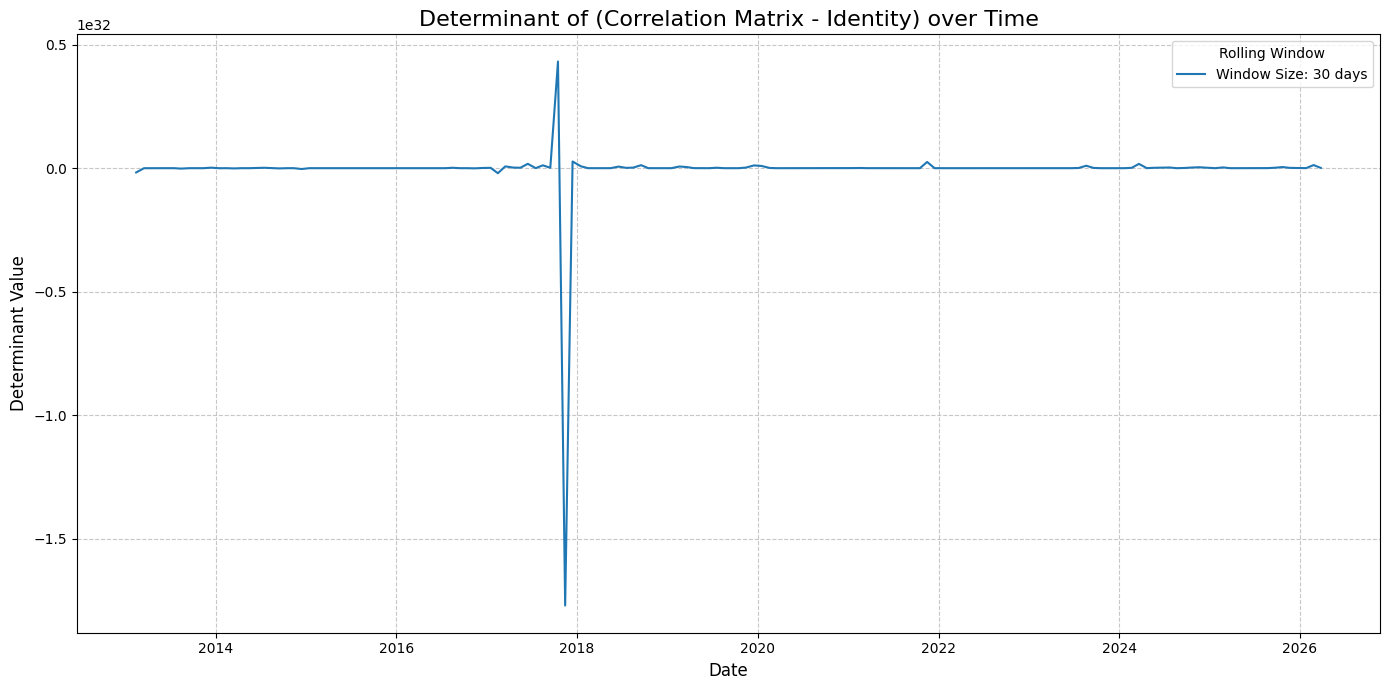


Analysis complete.


In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
import shutil
import numpy as np  # Import numpy for matrix operations

# Ensure these libraries are installed if you're running outside a managed environment like Colab
# If you get ModuleNotFoundError, uncomment and run these lines in your terminal:
# pip install yfinance pandas seaborn matplotlib numpy scipy

# Attempt to import Colab specific files module for download functionality
try:
    from google.colab import files
except ImportError:
    print("Running outside Google Colab, automatic file download will not work.")
    files = None

# --- Configuration for the analysis ---
ANIMATION_WINDOW_SIZE = 30  # As requested: rolling windows of 30 days for heatmaps
ANIMATION_STEP_SIZE = 21   # e.g., 21 trading days (~1 month) per frame, adjust for more/fewer frames
OUTPUT_FOLDER = 'correlation_heatmap_frames' # Folder for heatmap animation frames
IMAGE_DPI = 150 # Dots per inch for saved images (higher = better quality, larger files)

# For the determinant plot, we'll now specifically plot the determinant for the ANIMATION_WINDOW_SIZE
# If you want to plot determinants for OTHER window sizes, add them here:
DETERMINANT_WINDOW_STEPS = [ANIMATION_WINDOW_SIZE] # Only plot for the animation window size by default
# Example to add more: DETERMINANT_WINDOW_STEPS = [ANIMATION_WINDOW_SIZE, 63, 126, 252]
# --- End Configuration ---

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV (reliable source)"""
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    try:
        df = pd.read_csv(raw_url)
        tickers = df['Symbol'].tolist()
        tickers = [t.replace('.', '-') for t in tickers] # Clean symbols for yfinance
        return tickers
    except Exception as e:
        print(f"Error fetching S&P 500 tickers from GitHub: {e}")
        print("Falling back to a small, hardcoded list.")
        return ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'] # Fallback list for quick testing

def download_historical_data(tickers, start_date='2013-01-01'):
    """Download historical stock data for all S&P 500 components"""
    end_date = datetime.today().strftime('%Y-%m-%d')
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")

    # Using auto_adjust=True to automatically get adjusted closing prices
    # group_by='ticker' structures the DataFrame with tickers as top-level columns
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=True,
        progress=False # Suppress progress bar for cleaner output
    )

    # Handle single ticker download case vs. multiple tickers
    if isinstance(data.columns, pd.MultiIndex):
        closes = data.xs('Close', axis=1, level=1)
    else: # Case for single ticker download, or when 'data' might be a Series if only one ticker selected
        closes = data['Close'].to_frame() # Convert Series to DataFrame to maintain consistent structure

    # Drop any columns (tickers) that have no data at all across the entire period
    closes = closes.dropna(axis=1, how='all')
    print(f"Downloaded data for {closes.shape[1]} stocks with {len(closes)} dates.")
    return closes

def calculate_rolling_correlation_matrices(prices_df, window_size, step_size, method='spearman'):
    """
    Calculates rolling correlation matrices for daily returns.
    Returns a list of (end_date, correlation_matrix) tuples.
    """
    # Calculate daily returns, then drop any rows where all returns are NaN
    # (e.g., non-trading days where all stock prices are missing)
    returns = prices_df.pct_change().dropna(how='all')

    # Drop columns (tickers) that are entirely NaN after pct_change
    returns = returns.dropna(axis=1, how='all')

    if len(returns) < window_size:
        print(f"Warning: Not enough data ({len(returns)} days) for window size {window_size}. Skipping rolling correlation matrices.")
        return []

    rolling_matrices = []
    print(f"Calculating rolling {method} correlation matrices (Window: {window_size} days, Step: {step_size} days)...")

    # Iterate through the returns DataFrame to define rolling windows
    # The loop starts from the first possible end date of a full window
    for i in range(window_size - 1, len(returns), step_size):
        window_end_date = returns.index[i]
        window_start_date = returns.index[i - window_size + 1]

        # Select the data for the current window
        window_returns = returns.loc[window_start_date:window_end_date]

        # Drop tickers that have no data within this specific window to avoid NaN matrices
        # This is crucial for handling delisted stocks or stocks newly added to index
        window_returns = window_returns.dropna(axis=1, how='all')

        # Only calculate if there are at least two valid stocks and enough data points in the window
        # for a meaningful correlation calculation. (corr() needs at least 2 data points for each pair)
        if window_returns.shape[1] >= 2 and len(window_returns) >= window_size:
            corr_matrix = window_returns.corr(method=method)

            # Check if the calculated matrix itself is full of NaNs (e.g., all constant returns in window, or insufficient variance)
            if not corr_matrix.isnull().all().all():
                rolling_matrices.append((window_end_date, corr_matrix))
            # else:
                # print(f"  Skipping frame for {window_end_date.strftime('%Y-%m-%d')} due to NaN correlation matrix (e.g. constant returns in window).")
        # else:
            # print(f"  Skipping frame for {window_end_date.strftime('%Y-%m-%d')} due to insufficient valid data in window.")

    print(f"Calculated {len(rolling_matrices)} rolling correlation matrices.")
    return rolling_matrices

def plot_and_save_heatmap(corr_matrix, current_date, frame_num, output_folder, dpi):
    """
    Plots a single correlation heatmap and saves it as a PNG image.
    Hides ticker labels for clarity in animation.
    """
    plt.figure(figsize=(12, 10)) # Adjust figure size for animation frames if needed
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1, # Ensure consistent color scale
        vmax=1, # Ensure consistent color scale
        annot=False, # No annotations for a large matrix
        xticklabels=False, # Hide labels to prevent clutter
        yticklabels=False, # Hide labels to prevent clutter
        cbar_kws={'label': 'Correlation Coefficient'} # Add color bar label
    )
    plt.title(f'S&P 500 Rolling Correlation ({current_date.strftime("%Y-%m-%d")})', fontsize=16)

    # Save the figure
    filename = os.path.join(output_folder, f'heatmap_frame_{frame_num:04d}.png')
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close() # Close the plot to free up memory

def calculate_modified_determinant(corr_matrix):
    """
    Calculates the determinant of (correlation matrix - identity matrix).
    Returns NaN if the matrix is not square or if there are NaNs.
    """
    if corr_matrix.empty or corr_matrix.isnull().all().all():
        return np.nan

    # Drop any rows/columns that might have become all NaN due to previous filtering
    corr_matrix_clean = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

    if corr_matrix_clean.shape[0] == 0 or corr_matrix_clean.shape[0] != corr_matrix_clean.shape[1]:
        return np.nan # Determinant is only defined for non-empty square matrices

    # Convert to numpy array for numerical stability and operations
    np_corr_matrix = corr_matrix_clean.to_numpy()

    # Create an identity matrix of the same size
    identity_matrix = np.eye(np_corr_matrix.shape[0])

    # Subtract the identity matrix from the diagonal of the correlation matrix
    modified_matrix = np_corr_matrix - identity_matrix

    try:
        # Calculate the determinant
        det_val = np.linalg.det(modified_matrix)
        return det_val
    except np.linalg.LinAlgError as e:
        # This can happen if the matrix is singular or near-singular
        print(f"  Warning: Could not calculate determinant due to Linear Algebra Error: {e}")
        return np.nan

def plot_determinant_over_time(determinant_data_list):
    """
    Plots the modified determinant over time for multiple window sizes on the same graph.
    """
    plt.figure(figsize=(14, 7))
    for determinant_df, window_size in determinant_data_list:
        if not determinant_df.empty:
            plt.plot(determinant_df.index, determinant_df.values, label=f'Window Size: {window_size} days')
        else:
            print(f"No valid determinant values to plot for window size: {window_size}")

    plt.title('Determinant of (Correlation Matrix - Identity) over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Determinant Value', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Rolling Window', loc='best')
    plt.tight_layout()
    plt.show()

# --- Main execution flow ---
if __name__ == "__main__":
    # Create output folder for animation frames
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    # 1. Fetch S&P 500 tickers
    tickers = fetch_sp500_tickers()

    # 2. Download historical prices
    # Start date needs to be early enough to cover all rolling windows
    prices = download_historical_data(tickers, start_date='2013-01-01')

    # Filter out stocks with too many missing values over the entire period
    initial_valid_rows = len(prices)
    min_non_nan_threshold = int(initial_valid_rows * 0.8) # Require at least 80% non-NaN data
    prices_filtered = prices.dropna(axis=1, thresh=min_non_nan_threshold)

    if prices_filtered.empty:
        print("No valid stocks remaining after filtering for missing data. Exiting.")
        exit()

    print(f"Retaining {prices_filtered.shape[1]} stocks after filtering for missing data.")

    # --- Heatmap Animation Generation ---
    # Calculate rolling correlation matrices for the animation (30-day window)
    all_rolling_matrices_for_animation = calculate_rolling_correlation_matrices(
        prices_filtered,
        window_size=ANIMATION_WINDOW_SIZE, # Use the specified 30-day window
        step_size=ANIMATION_STEP_SIZE,
        method='spearman'
    )

    if all_rolling_matrices_for_animation:
        print(f"\nGenerating {len(all_rolling_matrices_for_animation)} heatmap frames (Window: {ANIMATION_WINDOW_SIZE} days)...")
        for i, (date, matrix) in enumerate(all_rolling_matrices_for_animation):
            plot_and_save_heatmap(matrix, date, i + 1, OUTPUT_FOLDER, IMAGE_DPI)
            if (i + 1) % 50 == 0:
                print(f"  Saved {i + 1} frames...")
        print("All heatmap frames saved.")

        zip_filename = f"{OUTPUT_FOLDER}.zip"
        print(f"\nCreating zip archive: {zip_filename}...")
        try:
            shutil.make_archive(OUTPUT_FOLDER, 'zip', OUTPUT_FOLDER)
            print("Zip archive created successfully.")

            if files: # Check if files module was imported successfully (i.e., in Colab)
                print(f"Initiating download of {zip_filename}...")
                files.download(zip_filename)
                print("Download should start shortly in your browser.")
            else:
                print("Not in Google Colab environment. Please manually download the zip file.")
                print(f"The zip file is located at: {os.path.abspath(zip_filename)}")

        except Exception as e:
            print(f"Error creating or downloading zip file: {e}")

        print(f"\nTo create a GIF from these frames (after downloading and unzipping), navigate to the '{OUTPUT_FOLDER}' directory in your terminal and run:")
        print(f"convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif")
        print("Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.")
        print("      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.")
    else:
        print("No rolling correlation matrices were generated for animation.")

    # --- Determinant Calculation and Plotting ---
    print("\n--- Calculating and plotting determinant over time ---")
    all_determinant_data_to_plot = []

    for window_size in DETERMINANT_WINDOW_STEPS: # Loop through desired window sizes for determinant plot
        print(f"Processing for determinant plot: Window Size = {window_size} days")
        determinant_values = []
        # Recalculate rolling matrices for each determinant window size
        # Use the same step_size for consistency in time alignment
        rolling_matrices_for_determinant = calculate_rolling_correlation_matrices(
            prices_filtered,
            window_size=window_size,
            step_size=ANIMATION_STEP_SIZE,
            method='spearman'
        )
        for date, matrix in rolling_matrices_for_determinant:
            determinant = calculate_modified_determinant(matrix)
            determinant_values.append((date, determinant))

        determinant_df = pd.DataFrame(determinant_values, columns=['Date', 'Determinant']).set_index('Date')
        determinant_df = determinant_df.dropna() # Remove any NaN determinant values
        all_determinant_data_to_plot.append((determinant_df, window_size))

    if all_determinant_data_to_plot:
        plot_determinant_over_time(all_determinant_data_to_plot)
    else:
        print("No determinant data was generated for plotting.")

    print("\nAnalysis complete.")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks with 3343 dates.
Retaining 465 stocks after filtering for missing data.


/tmp/ipykernel_4226/1578178720.py:74: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


Calculating rolling spearman correlation matrices (Window: 30 days, Step: 30 days)...
Calculated 111 rolling correlation matrices.

Generating 111 heatmap frames (Window: 30 days)...
  Saved 50 frames...
  Saved 100 frames...
All heatmap frames saved.

Creating zip archive: correlation_heatmap_frames.zip...
Zip archive created successfully.
Initiating download of correlation_heatmap_frames.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download should start shortly in your browser.

To create a GIF from these frames (after downloading and unzipping), navigate to the 'correlation_heatmap_frames' directory in your terminal and run:
convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif
Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.
      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.

--- Calculating and plotting determinant over time ---
Processing for determinant plot: Window Size = 30 days
Calculating rolling spearman correlation matrices (Window: 30 days, Step: 30 days)...


/tmp/ipykernel_4226/1578178720.py:74: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


Calculated 111 rolling correlation matrices.


/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


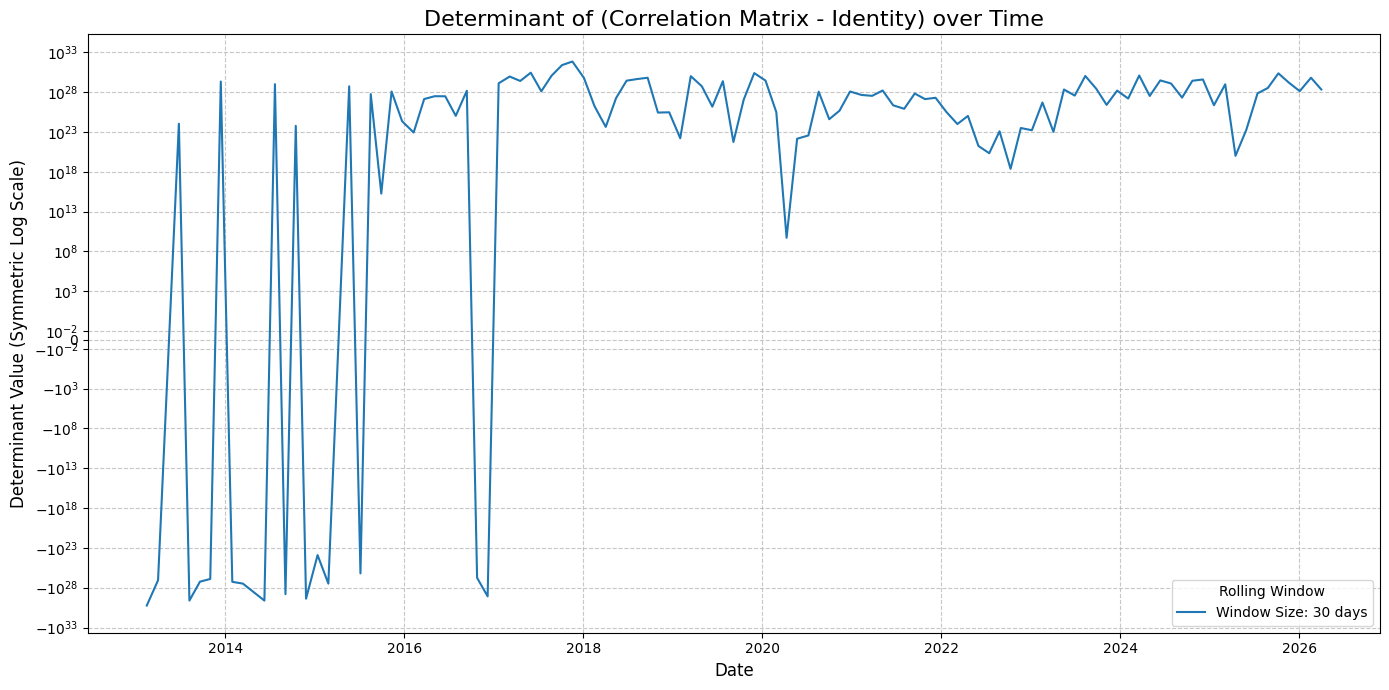


Analysis complete.


In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
import shutil
import numpy as np  # Import numpy for matrix operations

# Ensure these libraries are installed if you're running outside a managed environment like Colab
# If you get ModuleNotFoundError, uncomment and run these lines in your terminal:
# pip install yfinance pandas seaborn matplotlib numpy scipy

# Attempt to import Colab specific files module for download functionality
try:
    from google.colab import files
except ImportError:
    print("Running outside Google Colab, automatic file download will not work.")
    files = None

# --- Configuration for the analysis ---
ANIMATION_WINDOW_SIZE = 30  # As requested: rolling windows of 30 days for heatmaps
ANIMATION_STEP_SIZE = 30   # e.g., 21 trading days (~1 month) per frame, adjust for more/fewer frames
OUTPUT_FOLDER = 'correlation_heatmap_frames' # Folder for heatmap animation frames
IMAGE_DPI = 150 # Dots per inch for saved images (higher = better quality, larger files)

# For the determinant plot, we'll now specifically plot the determinant for the ANIMATION_WINDOW_SIZE
# If you want to plot determinants for OTHER window sizes, add them here:
DETERMINANT_WINDOW_STEPS = [ANIMATION_WINDOW_SIZE] # Only plot for the animation window size by default
# Example to add more: DETERMINANT_WINDOW_STEPS = [ANIMATION_WINDOW_SIZE, 63, 126, 252]
# --- End Configuration ---

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV (reliable source)"""
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    try:
        df = pd.read_csv(raw_url)
        tickers = df['Symbol'].tolist()
        tickers = [t.replace('.', '-') for t in tickers] # Clean symbols for yfinance
        return tickers
    except Exception as e:
        print(f"Error fetching S&P 500 tickers from GitHub: {e}")
        print("Falling back to a small, hardcoded list.")
        return ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'] # Fallback list for quick testing

def download_historical_data(tickers, start_date='2013-01-01'):
    """Download historical stock data for all S&P 500 components"""
    end_date = datetime.today().strftime('%Y-%m-%d')
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")

    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=True,
        progress=False
    )

    if isinstance(data.columns, pd.MultiIndex):
        closes = data.xs('Close', axis=1, level=1)
    else:
        closes = data['Close'].to_frame()

    closes = closes.dropna(axis=1, how='all')
    print(f"Downloaded data for {closes.shape[1]} stocks with {len(closes)} dates.")
    return closes

def calculate_rolling_correlation_matrices(prices_df, window_size, step_size, method='spearman'):
    """
    Calculates rolling correlation matrices for daily returns.
    Returns a list of (end_date, correlation_matrix) tuples.
    """
    returns = prices_df.pct_change().dropna(how='all')
    returns = returns.dropna(axis=1, how='all')

    if len(returns) < window_size:
        print(f"Warning: Not enough data ({len(returns)} days) for window size {window_size}. Skipping rolling correlation matrices.")
        return []

    rolling_matrices = []
    print(f"Calculating rolling {method} correlation matrices (Window: {window_size} days, Step: {step_size} days)...")

    for i in range(window_size - 1, len(returns), step_size):
        window_end_date = returns.index[i]
        window_start_date = returns.index[i - window_size + 1]

        window_returns = returns.loc[window_start_date:window_end_date]
        window_returns = window_returns.dropna(axis=1, how='all')

        if window_returns.shape[1] >= 2 and len(window_returns) >= window_size:
            corr_matrix = window_returns.corr(method=method)

            if not corr_matrix.isnull().all().all():
                rolling_matrices.append((window_end_date, corr_matrix))

    print(f"Calculated {len(rolling_matrices)} rolling correlation matrices.")
    return rolling_matrices

def plot_and_save_heatmap(corr_matrix, current_date, frame_num, output_folder, dpi):
    """
    Plots a single correlation heatmap and saves it as a PNG image.
    Hides ticker labels for clarity in animation.
    """
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=False,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title(f'S&P 500 Rolling Correlation ({current_date.strftime("%Y-%m-%d")})', fontsize=16)

    filename = os.path.join(output_folder, f'heatmap_frame_{frame_num:04d}.png')
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close()

def calculate_modified_determinant(corr_matrix):
    """
    Calculates the determinant of (correlation matrix - identity matrix).
    Returns NaN if the matrix is not square or if there are NaNs.
    """
    if corr_matrix.empty or corr_matrix.isnull().all().all():
        return np.nan

    corr_matrix_clean = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

    if corr_matrix_clean.shape[0] == 0 or corr_matrix_clean.shape[0] != corr_matrix_clean.shape[1]:
        return np.nan

    np_corr_matrix = corr_matrix_clean.to_numpy()
    identity_matrix = np.eye(np_corr_matrix.shape[0])
    modified_matrix = np_corr_matrix - identity_matrix

    try:
        det_val = np.linalg.det(modified_matrix)
        return det_val
    except np.linalg.LinAlgError as e:
        print(f"  Warning: Could not calculate determinant due to Linear Algebra Error: {e}")
        return np.nan

def plot_determinant_over_time(determinant_data_list):
    """
    Plots the modified determinant over time for multiple window sizes on the same graph,
    using a symmetric log scale for the y-axis.
    """
    plt.figure(figsize=(14, 7))
    for determinant_df, window_size in determinant_data_list:
        if not determinant_df.empty:
            plt.plot(determinant_df.index, determinant_df.values, label=f'Window Size: {window_size} days')
        else:
            print(f"No valid determinant values to plot for window size: {window_size}")

    plt.title('Determinant of (Correlation Matrix - Identity) over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Determinant Value (Symmetric Log Scale)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Rolling Window', loc='best')

    # Apply symmetric log scale to the y-axis
    plt.yscale('symlog', linthresh=0.01) # linthresh sets the range around zero that is linear
                                      # Adjust linthresh based on expected determinant values near zero
    plt.tight_layout()
    plt.show()

# --- Main execution flow ---
if __name__ == "__main__":
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    tickers = fetch_sp500_tickers()
    prices = download_historical_data(tickers, start_date='2013-01-01')

    initial_valid_rows = len(prices)
    min_non_nan_threshold = int(initial_valid_rows * 0.8)
    prices_filtered = prices.dropna(axis=1, thresh=min_non_nan_threshold)

    if prices_filtered.empty:
        print("No valid stocks remaining after filtering for missing data. Exiting.")
        exit()

    print(f"Retaining {prices_filtered.shape[1]} stocks after filtering for missing data.")

    # --- Heatmap Animation Generation ---
    all_rolling_matrices_for_animation = calculate_rolling_correlation_matrices(
        prices_filtered,
        window_size=ANIMATION_WINDOW_SIZE,
        step_size=ANIMATION_STEP_SIZE,
        method='spearman'
    )

    if all_rolling_matrices_for_animation:
        print(f"\nGenerating {len(all_rolling_matrices_for_animation)} heatmap frames (Window: {ANIMATION_WINDOW_SIZE} days)...")
        for i, (date, matrix) in enumerate(all_rolling_matrices_for_animation):
            plot_and_save_heatmap(matrix, date, i + 1, OUTPUT_FOLDER, IMAGE_DPI)
            if (i + 1) % 50 == 0:
                print(f"  Saved {i + 1} frames...")
        print("All heatmap frames saved.")

        zip_filename = f"{OUTPUT_FOLDER}.zip"
        print(f"\nCreating zip archive: {zip_filename}...")
        try:
            shutil.make_archive(OUTPUT_FOLDER, 'zip', OUTPUT_FOLDER)
            print("Zip archive created successfully.")

            if files:
                print(f"Initiating download of {zip_filename}...")
                files.download(zip_filename)
                print("Download should start shortly in your browser.")
            else:
                print("Not in Google Colab environment. Please manually download the zip file.")
                print(f"The zip file is located at: {os.path.abspath(zip_filename)}")

        except Exception as e:
            print(f"Error creating or downloading zip file: {e}")

        print(f"\nTo create a GIF from these frames (after downloading and unzipping), navigate to the '{OUTPUT_FOLDER}' directory in your terminal and run:")
        print(f"convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif")
        print("Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.")
        print("      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.")
    else:
        print("No rolling correlation matrices were generated for animation.")

    # --- Determinant Calculation and Plotting ---
    print("\n--- Calculating and plotting determinant over time ---")
    all_determinant_data_to_plot = []

    for window_size in DETERMINANT_WINDOW_STEPS:
        print(f"Processing for determinant plot: Window Size = {window_size} days")
        determinant_values = []
        rolling_matrices_for_determinant = calculate_rolling_correlation_matrices(
            prices_filtered,
            window_size=window_size,
            step_size=ANIMATION_STEP_SIZE,
            method='spearman'
        )
        for date, matrix in rolling_matrices_for_determinant:
            determinant = calculate_modified_determinant(matrix)
            determinant_values.append((date, determinant))

        determinant_df = pd.DataFrame(determinant_values, columns=['Date', 'Determinant']).set_index('Date')
        determinant_df = determinant_df.dropna()
        all_determinant_data_to_plot.append((determinant_df, window_size))

    if all_determinant_data_to_plot:
        plot_determinant_over_time(all_determinant_data_to_plot)
    else:
        print("No determinant data was generated for plotting.")

    print("\nAnalysis complete.")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks with 3343 dates.
Retaining 465 stocks after filtering for missing data.


/tmp/ipykernel_4226/831661308.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')



Generating 158 heatmap frames (Window: 30 days, Step: 21 days)...
  Saved 50 frames...
  Saved 100 frames...
  Saved 150 frames...
All heatmap frames saved.

Creating zip archive: correlation_heatmap_frames.zip...
Zip archive created successfully.
Initiating download of correlation_heatmap_frames.zip...


<IPython.core.display.Javascript object>

...

/tmp/ipykernel_4226/831661308.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


  Calculating determinant for Window/Step Size: 200 days


/tmp/ipykernel_4226/831661308.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


  Calculating determinant for Window/Step Size: 300 days


/tmp/ipykernel_4226/831661308.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


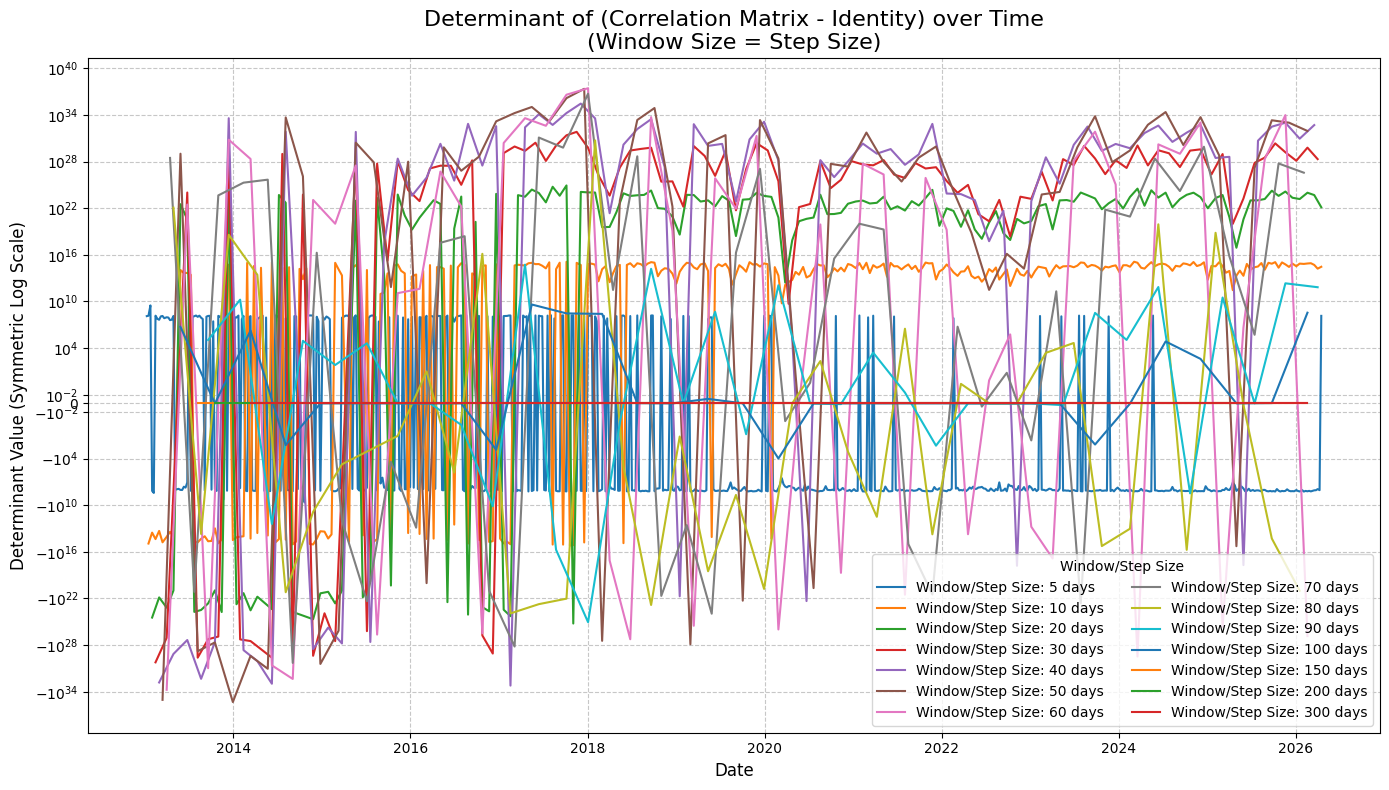


Analysis complete.


In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
import shutil
import numpy as np

try:
    from google.colab import files
except ImportError:
    print("Running outside Google Colab, automatic file download will not work.")
    files = None

# --- Configuration for the analysis ---
ANIMATION_WINDOW_SIZE = 30  # Fixed: rolling window of 30 days for heatmaps
ANIMATION_STEP_SIZE = 21    # Default step size for heatmaps (~1 month)
OUTPUT_FOLDER = 'correlation_heatmap_frames'
IMAGE_DPI = 150

# --- NEW: Configuration for the Determinant Plot ---
# List of sizes where window_size = step_size
DETERMINANT_PLOT_WINDOW_STEP_SIZES = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 300]
# --- End Configuration ---

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV (reliable source)"""
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    try:
        df = pd.read_csv(raw_url)
        tickers = df['Symbol'].tolist()
        tickers = [t.replace('.', '-') for t in tickers]
        return tickers
    except Exception as e:
        print(f"Error fetching S&P 500 tickers from GitHub: {e}")
        print("Falling back to a small, hardcoded list.")
        return ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

def download_historical_data(tickers, start_date='2013-01-01'):
    """Download historical stock data for all S&P 500 components"""
    end_date = datetime.today().strftime('%Y-%m-%d')
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=True,
        progress=False
    )
    if isinstance(data.columns, pd.MultiIndex):
        closes = data.xs('Close', axis=1, level=1)
    else:
        closes = data['Close'].to_frame()
    closes = closes.dropna(axis=1, how='all')
    print(f"Downloaded data for {closes.shape[1]} stocks with {len(closes)} dates.")
    return closes

def calculate_rolling_correlation_matrices(prices_df, window_size, step_size, method='spearman'):
    """
    Calculates rolling correlation matrices for daily returns.
    Returns a list of (end_date, correlation_matrix) tuples.
    """
    returns = prices_df.pct_change().dropna(how='all')
    returns = returns.dropna(axis=1, how='all')

    if len(returns) < window_size:
        print(f"Warning: Not enough data ({len(returns)} days) for window size {window_size}. Skipping rolling correlation matrices.")
        return []

    rolling_matrices = []
    # print(f"Calculating rolling {method} correlation matrices (Window: {window_size} days, Step: {step_size} days)...") # Suppress frequent print

    for i in range(window_size - 1, len(returns), step_size):
        window_end_date = returns.index[i]
        window_start_date = returns.index[i - window_size + 1]

        window_returns = returns.loc[window_start_date:window_end_date]
        window_returns = window_returns.dropna(axis=1, how='all')

        if window_returns.shape[1] >= 2 and len(window_returns) >= window_size:
            corr_matrix = window_returns.corr(method=method)

            if not corr_matrix.isnull().all().all():
                rolling_matrices.append((window_end_date, corr_matrix))

    # print(f"Calculated {len(rolling_matrices)} rolling correlation matrices.") # Suppress frequent print
    return rolling_matrices

def plot_and_save_heatmap(corr_matrix, current_date, frame_num, output_folder, dpi):
    """
    Plots a single correlation heatmap and saves it as a PNG image.
    Hides ticker labels for clarity in animation.
    """
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=False,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title(f'S&P 500 Rolling Correlation ({current_date.strftime("%Y-%m-%d")})', fontsize=16)

    filename = os.path.join(output_folder, f'heatmap_frame_{frame_num:04d}.png')
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close()

def calculate_modified_determinant(corr_matrix):
    """
    Calculates the determinant of (correlation matrix - identity matrix).
    Returns NaN if the matrix is not square or if there are NaNs.
    """
    if corr_matrix.empty or corr_matrix.isnull().all().all():
        return np.nan

    corr_matrix_clean = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

    if corr_matrix_clean.shape[0] == 0 or corr_matrix_clean.shape[0] != corr_matrix_clean.shape[1]:
        return np.nan

    np_corr_matrix = corr_matrix_clean.to_numpy()
    identity_matrix = np.eye(np_corr_matrix.shape[0])
    modified_matrix = np_corr_matrix - identity_matrix

    try:
        det_val = np.linalg.det(modified_matrix)
        return det_val
    except np.linalg.LinAlgError as e:
        # print(f"  Warning: Could not calculate determinant due to Linear Algebra Error: {e}") # Suppress frequent print
        return np.nan

def plot_determinant_over_time(determinant_data_list_of_tuples):
    """
    Plots the modified determinant over time for cases where window_size = step_size,
    using a symmetric log scale for the y-axis.
    """
    plt.figure(figsize=(14, 8))
    for determinant_df, current_size in determinant_data_list_of_tuples:
        if not determinant_df.empty:
            plt.plot(determinant_df.index, determinant_df.values, label=f'Window/Step Size: {current_size} days')
        else:
            print(f"No valid determinant values to plot for Window/Step Size: {current_size} days")

    plt.title(f'Determinant of (Correlation Matrix - Identity) over Time\n(Window Size = Step Size)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Determinant Value (Symmetric Log Scale)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Window/Step Size', loc='best', ncol=2)
    plt.yscale('symlog', linthresh=0.01) # Adjust linthresh based on expected determinant values near zero
    plt.tight_layout()
    plt.show()

# --- Main execution flow ---
if __name__ == "__main__":
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    tickers = fetch_sp500_tickers()
    prices = download_historical_data(tickers, start_date='2013-01-01')

    initial_valid_rows = len(prices)
    min_non_nan_threshold = int(initial_valid_rows * 0.8)
    prices_filtered = prices.dropna(axis=1, thresh=min_non_nan_threshold)

    if prices_filtered.empty:
        print("No valid stocks remaining after filtering for missing data. Exiting.")
        exit()

    print(f"Retaining {prices_filtered.shape[1]} stocks after filtering for missing data.")

    # --- Heatmap Animation Generation (using ANIMATION_WINDOW_SIZE and ANIMATION_STEP_SIZE) ---
    all_rolling_matrices_for_animation = calculate_rolling_correlation_matrices(
        prices_filtered,
        window_size=ANIMATION_WINDOW_SIZE,
        step_size=ANIMATION_STEP_SIZE,
        method='spearman'
    )

    if all_rolling_matrices_for_animation:
        print(f"\nGenerating {len(all_rolling_matrices_for_animation)} heatmap frames (Window: {ANIMATION_WINDOW_SIZE} days, Step: {ANIMATION_STEP_SIZE} days)...")
        for i, (date, matrix) in enumerate(all_rolling_matrices_for_animation):
            plot_and_save_heatmap(matrix, date, i + 1, OUTPUT_FOLDER, IMAGE_DPI)
            if (i + 1) % 50 == 0:
                print(f"  Saved {i + 1} frames...")
        print("All heatmap frames saved.")

        zip_filename = f"{OUTPUT_FOLDER}.zip"
        print(f"\nCreating zip archive: {zip_filename}...")
        try:
            shutil.make_archive(OUTPUT_FOLDER, 'zip', OUTPUT_FOLDER)
            print("Zip archive created successfully.")

            if files:
                print(f"Initiating download of {zip_filename}...")
                files.download(zip_filename)
                print("Download should start shortly in your browser.")
            else:
                print("Not in Google Colab environment. Please manually download the zip file.")
                print(f"The zip file is located at: {os.path.abspath(zip_filename)}")

        except Exception as e:
            print(f"Error creating or downloading zip file: {e}")

        print(f"\nTo create a GIF from these frames (after downloading and unzipping), navigate to the '{OUTPUT_FOLDER}' directory in your terminal and run:")
        print(f"convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif")
        print("Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.")
        print("      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.")
    else:
        print("No rolling correlation matrices were generated for animation.")

    # --- Determinant Calculation and Plotting for various (Window=Step) Sizes ---
    print("\n--- Calculating and plotting determinant for various (Window Size = Step Size) ---")
    all_determinant_data_to_plot = []

    # Loop through each desired size where window_size and step_size are the same
    for current_size in DETERMINANT_PLOT_WINDOW_STEP_SIZES:
        print(f"  Calculating determinant for Window/Step Size: {current_size} days")
        determinant_values = []
        # Calculate rolling matrices using current_size for both window_size and step_size
        rolling_matrices_for_determinant_plot = calculate_rolling_correlation_matrices(
            prices_filtered,
            window_size=current_size, # Window size is current_size
            step_size=current_size,   # Step size is also current_size
            method='spearman'
        )
        for date, matrix in rolling_matrices_for_determinant_plot:
            determinant = calculate_modified_determinant(matrix)
            determinant_values.append((date, determinant))

        determinant_df = pd.DataFrame(determinant_values, columns=['Date', 'Determinant']).set_index('Date')
        determinant_df = determinant_df.dropna()
        all_determinant_data_to_plot.append((determinant_df, current_size)) # Store with the common size

    if all_determinant_data_to_plot:
        # Plot all determinant lines on one graph
        plot_determinant_over_time(all_determinant_data_to_plot) # No need to pass fixed_window_size anymore
    else:
        print("No determinant data was generated for plotting.")

    print("\nAnalysis complete.")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DAY']: YFTzMissingError('possibly delisted; no timezone found')


Downloaded data for 502 stocks with 7875 dates.
Retaining 359 stocks after filtering for missing data.


/tmp/ipykernel_4226/3698599551.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')



Generating 262 heatmap frames (Window: 30 days, Step: 30 days)...
  Saved 50 frames...
  Saved 100 frames...
  Saved 150 frames...
  Saved 200 frames...
  Saved 250 frames...
All heatmap frames saved.

Creating zip archive: correlation_heatmap_frames.zip...
Zip archive created successfully.
Initiating download of correlation_heatmap_frames.zip...


<IPython.core.display.Javascript object>

...

/tmp/ipykernel_4226/3698599551.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


  Calculating determinant for Window/Step Size: 200 days


/tmp/ipykernel_4226/3698599551.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


  Calculating determinant for Window/Step Size: 300 days


/tmp/ipykernel_4226/3698599551.py:65: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_df.pct_change().dropna(how='all')


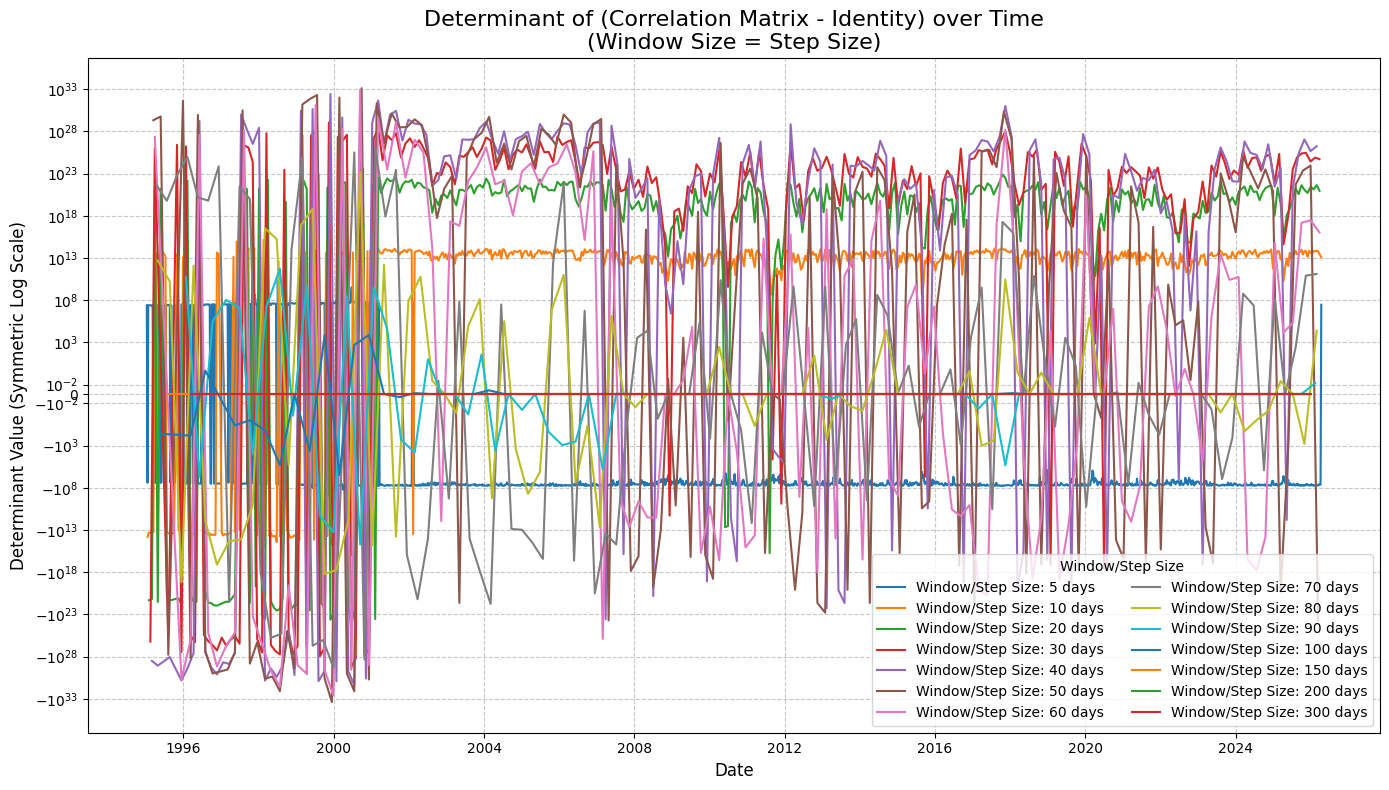


Analysis complete.


In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import os
import shutil
import numpy as np

try:
    from google.colab import files
except ImportError:
    print("Running outside Google Colab, automatic file download will not work.")
    files = None

# --- Configuration for the analysis ---
ANIMATION_WINDOW_SIZE = 30  # Fixed: rolling window of 30 days for heatmaps
ANIMATION_STEP_SIZE = 30    # Default step size for heatmaps (~1 month)
OUTPUT_FOLDER = 'correlation_heatmap_frames'
IMAGE_DPI = 150

# --- NEW: Configuration for the Determinant Plot ---
# List of sizes where window_size = step_size
DETERMINANT_PLOT_WINDOW_STEP_SIZES = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 300]
# --- End Configuration ---

def fetch_sp500_tickers():
    """Fetch S&P 500 constituents from GitHub CSV (reliable source)"""
    raw_url = "https://raw.githubusercontent.com/fja05680/sp500/master/sp500.csv"
    try:
        df = pd.read_csv(raw_url)
        tickers = df['Symbol'].tolist()
        tickers = [t.replace('.', '-') for t in tickers]
        return tickers
    except Exception as e:
        print(f"Error fetching S&P 500 tickers from GitHub: {e}")
        print("Falling back to a small, hardcoded list.")
        return ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

def download_historical_data(tickers, start_date='1990-01-01'):
    """Download historical stock data for all S&P 500 components"""
    end_date = datetime.today().strftime('%Y-%m-%d')
    print(f"Downloading data for {len(tickers)} tickers from {start_date} to {end_date}...")
    data = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        group_by='ticker',
        auto_adjust=True,
        progress=False
    )
    if isinstance(data.columns, pd.MultiIndex):
        closes = data.xs('Close', axis=1, level=1)
    else:
        closes = data['Close'].to_frame()
    closes = closes.dropna(axis=1, how='all')
    print(f"Downloaded data for {closes.shape[1]} stocks with {len(closes)} dates.")
    return closes

def calculate_rolling_correlation_matrices(prices_df, window_size, step_size, method='spearman'):
    """
    Calculates rolling correlation matrices for daily returns.
    Returns a list of (end_date, correlation_matrix) tuples.
    """
    returns = prices_df.pct_change().dropna(how='all')
    returns = returns.dropna(axis=1, how='all')

    if len(returns) < window_size:
        print(f"Warning: Not enough data ({len(returns)} days) for window size {window_size}. Skipping rolling correlation matrices.")
        return []

    rolling_matrices = []
    # print(f"Calculating rolling {method} correlation matrices (Window: {window_size} days, Step: {step_size} days)...") # Suppress frequent print

    for i in range(window_size - 1, len(returns), step_size):
        window_end_date = returns.index[i]
        window_start_date = returns.index[i - window_size + 1]

        window_returns = returns.loc[window_start_date:window_end_date]
        window_returns = window_returns.dropna(axis=1, how='all')

        if window_returns.shape[1] >= 2 and len(window_returns) >= window_size:
            corr_matrix = window_returns.corr(method=method)

            if not corr_matrix.isnull().all().all():
                rolling_matrices.append((window_end_date, corr_matrix))

    # print(f"Calculated {len(rolling_matrices)} rolling correlation matrices.") # Suppress frequent print
    return rolling_matrices

def plot_and_save_heatmap(corr_matrix, current_date, frame_num, output_folder, dpi):
    """
    Plots a single correlation heatmap and saves it as a PNG image.
    Hides ticker labels for clarity in animation.
    """
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        annot=False,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Correlation Coefficient'}
    )
    plt.title(f'S&P 500 Rolling Correlation ({current_date.strftime("%Y-%m-%d")})', fontsize=16)

    filename = os.path.join(output_folder, f'heatmap_frame_{frame_num:04d}.png')
    plt.savefig(filename, dpi=dpi, bbox_inches='tight')
    plt.close()

def calculate_modified_determinant(corr_matrix):
    """
    Calculates the determinant of (correlation matrix - identity matrix).
    Returns NaN if the matrix is not square or if there are NaNs.
    """
    if corr_matrix.empty or corr_matrix.isnull().all().all():
        return np.nan

    corr_matrix_clean = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

    if corr_matrix_clean.shape[0] == 0 or corr_matrix_clean.shape[0] != corr_matrix_clean.shape[1]:
        return np.nan

    np_corr_matrix = corr_matrix_clean.to_numpy()
    identity_matrix = np.eye(np_corr_matrix.shape[0])
    modified_matrix = np_corr_matrix - identity_matrix

    try:
        det_val = np.linalg.det(modified_matrix)
        return det_val
    except np.linalg.LinAlgError as e:
        # print(f"  Warning: Could not calculate determinant due to Linear Algebra Error: {e}") # Suppress frequent print
        return np.nan

def plot_determinant_over_time(determinant_data_list_of_tuples):
    """
    Plots the modified determinant over time for cases where window_size = step_size,
    using a symmetric log scale for the y-axis.
    """
    plt.figure(figsize=(14, 8))
    for determinant_df, current_size in determinant_data_list_of_tuples:
        if not determinant_df.empty:
            plt.plot(determinant_df.index, determinant_df.values, label=f'Window/Step Size: {current_size} days')
        else:
            print(f"No valid determinant values to plot for Window/Step Size: {current_size} days")

    plt.title(f'Determinant of (Correlation Matrix - Identity) over Time\n(Window Size = Step Size)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Determinant Value (Symmetric Log Scale)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Window/Step Size', loc='best', ncol=2)
    plt.yscale('symlog', linthresh=0.01) # Adjust linthresh based on expected determinant values near zero
    plt.tight_layout()
    plt.show()

# --- Main execution flow ---
if __name__ == "__main__":
    os.makedirs(OUTPUT_FOLDER, exist_ok=True)

    tickers = fetch_sp500_tickers()
    prices = download_historical_data(tickers, start_date='1995-01-01')

    initial_valid_rows = len(prices)
    min_non_nan_threshold = int(initial_valid_rows * 0.8)
    prices_filtered = prices.dropna(axis=1, thresh=min_non_nan_threshold)

    if prices_filtered.empty:
        print("No valid stocks remaining after filtering for missing data. Exiting.")
        exit()

    print(f"Retaining {prices_filtered.shape[1]} stocks after filtering for missing data.")

    # --- Heatmap Animation Generation (using ANIMATION_WINDOW_SIZE and ANIMATION_STEP_SIZE) ---
    all_rolling_matrices_for_animation = calculate_rolling_correlation_matrices(
        prices_filtered,
        window_size=ANIMATION_WINDOW_SIZE,
        step_size=ANIMATION_STEP_SIZE,
        method='spearman'
    )

    if all_rolling_matrices_for_animation:
        print(f"\nGenerating {len(all_rolling_matrices_for_animation)} heatmap frames (Window: {ANIMATION_WINDOW_SIZE} days, Step: {ANIMATION_STEP_SIZE} days)...")
        for i, (date, matrix) in enumerate(all_rolling_matrices_for_animation):
            plot_and_save_heatmap(matrix, date, i + 1, OUTPUT_FOLDER, IMAGE_DPI)
            if (i + 1) % 50 == 0:
                print(f"  Saved {i + 1} frames...")
        print("All heatmap frames saved.")

        zip_filename = f"{OUTPUT_FOLDER}.zip"
        print(f"\nCreating zip archive: {zip_filename}...")
        try:
            shutil.make_archive(OUTPUT_FOLDER, 'zip', OUTPUT_FOLDER)
            print("Zip archive created successfully.")

            if files:
                print(f"Initiating download of {zip_filename}...")
                files.download(zip_filename)
                print("Download should start shortly in your browser.")
            else:
                print("Not in Google Colab environment. Please manually download the zip file.")
                print(f"The zip file is located at: {os.path.abspath(zip_filename)}")

        except Exception as e:
            print(f"Error creating or downloading zip file: {e}")

        print(f"\nTo create a GIF from these frames (after downloading and unzipping), navigate to the '{OUTPUT_FOLDER}' directory in your terminal and run:")
        print(f"convert -delay 10 -loop 0 heatmap_frame_*.png correlation_animation.gif")
        print("Note: 'convert' is a command from ImageMagick. You may need to install it on your local machine.")
        print("      '-delay 10' sets frame delay to 0.1 seconds. '-loop 0' makes it loop indefinitely.")
    else:
        print("No rolling correlation matrices were generated for animation.")

    # --- Determinant Calculation and Plotting for various (Window=Step) Sizes ---
    print("\n--- Calculating and plotting determinant for various (Window Size = Step Size) ---")
    all_determinant_data_to_plot = []

    # Loop through each desired size where window_size and step_size are the same
    for current_size in DETERMINANT_PLOT_WINDOW_STEP_SIZES:
        print(f"  Calculating determinant for Window/Step Size: {current_size} days")
        determinant_values = []
        # Calculate rolling matrices using current_size for both window_size and step_size
        rolling_matrices_for_determinant_plot = calculate_rolling_correlation_matrices(
            prices_filtered,
            window_size=current_size, # Window size is current_size
            step_size=current_size,   # Step size is also current_size
            method='spearman'
        )
        for date, matrix in rolling_matrices_for_determinant_plot:
            determinant = calculate_modified_determinant(matrix)
            determinant_values.append((date, determinant))

        determinant_df = pd.DataFrame(determinant_values, columns=['Date', 'Determinant']).set_index('Date')
        determinant_df = determinant_df.dropna()
        all_determinant_data_to_plot.append((determinant_df, current_size)) # Store with the common size

    if all_determinant_data_to_plot:
        # Plot all determinant lines on one graph
        plot_determinant_over_time(all_determinant_data_to_plot) # No need to pass fixed_window_size anymore
    else:
        print("No determinant data was generated for plotting.")

    print("\nAnalysis complete.")

# S&P 500

In [ ]:
import pandas as pd
import yfinance as yf
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0"
}

html = requests.get(url, headers=headers).text
sp500_table = pd.read_html(html)[0]

sp500_tickers = sp500_table["Symbol"].str.replace(".", "-", regex=False).tolist()

sp500_data = yf.download(
    sp500_tickers,
    start="2010-01-01",
    auto_adjust=True,
    progress=True
)["Close"]

sp500_data.to_csv("sp500_constituents_prices.csv")
print(sp500_data.shape)

In [ ]:
from google.colab import files

sp500_data.to_csv("sp500_constituents_prices.csv")
files.download("sp500_constituents_prices.csv")

In [ ]:
import pandas as pd
import numpy as np

# Keep stocks with at least 5 years of observations
min_obs = 252 * 5
sp500_clean = sp500_data.loc[:, sp500_data.notna().sum() >= min_obs]

print("Original number of stocks:", sp500_data.shape[1])
print("Stocks after filtering:", sp500_clean.shape[1])

# Compute daily returns
sp500_returns = sp500_clean.pct_change().dropna(how="all")
print(sp500_returns.shape)

Correlation heatmap for top 20 stocks

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top20 = sp500_clean.notna().sum().sort_values(ascending=False).head(20).index
returns20 = sp500_clean[top20].pct_change().dropna()

corr20 = returns20.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr20, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("S&P 500 Constituents: Daily Return Correlation Heatmap (Top 20)")
plt.tight_layout()
plt.show()

Distribution of pairwise correlations

In [ ]:
corr_matrix = sp500_returns.corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()

plt.figure(figsize=(8, 5))
sns.histplot(upper, bins=30, kde=True)
plt.title("Distribution of Pairwise Correlations: S&P 500 Constituents")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Rolling correlation between two major stocks

In [ ]:
pair = ["AAPL", "MSFT"]

pair_returns = sp500_clean[pair].pct_change().dropna()
rolling_corr = pair_returns[pair[0]].rolling(60).corr(pair_returns[pair[1]])

plt.figure(figsize=(12, 5))
plt.plot(rolling_corr, color="navy")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("60-Day Rolling Correlation: AAPL vs MSFT")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

Average rolling correlation across top 10 stocks

In [ ]:
top10 = sp500_clean.notna().sum().sort_values(ascending=False).head(10).index
ret10 = sp500_clean[top10].pct_change().dropna()

window = 60
avg_corr = []

for i in range(window, len(ret10)):
    c = ret10.iloc[i-window:i].corr()
    vals = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack()
    avg_corr.append(vals.mean())

avg_corr = pd.Series(avg_corr, index=ret10.index[window:])

plt.figure(figsize=(12, 5))
plt.plot(avg_corr, color="darkred")
plt.title("Average 60-Day Rolling Correlation: Top 10 S&P 500 Stocks")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.tight_layout()
plt.show()

Clustermap

In [ ]:
sns.clustermap(
    corr20,
    cmap="coolwarm",
    center=0,
    figsize=(12, 12),
    linewidths=0.2
)
plt.suptitle("S&P 500 Constituents Correlation Clustermap", y=1.02)
plt.show()

#Ibovespa

In [ ]:
import pandas as pd
import yfinance as yf

# Current Ibovespa constituents in Yahoo format
ibov_tickers = [
    "ALOS3.SA","ABEV3.SA","ASAI3.SA","AZUL4.SA","B3SA3.SA","BBSE3.SA",
    "BBDC3.SA","BBDC4.SA","BBAS3.SA","BRKM5.SA","BRAV3.SA","BRFS3.SA",
    "BPAC11.SA","CRFB3.SA","CCRO3.SA","CMIG4.SA","COGN3.SA","CPLE6.SA",
    "CSAN3.SA","CPFE3.SA","CMIN3.SA","CVCB3.SA","CYRE3.SA","DXCO3.SA",
    "ELET3.SA","ELET6.SA","EMBR3.SA","ENGI11.SA","ENEV3.SA","EGIE3.SA",
    "EQTL3.SA","EZTC3.SA","FLRY3.SA","GGBR4.SA","GOAU4.SA","NTCO3.SA",
    "HAPV3.SA","HYPE3.SA","IGTI11.SA","IRBR3.SA","ITSA4.SA","ITUB4.SA",
    "JBSS3.SA","KLBN11.SA","RENT3.SA","LWSA3.SA","MGLU3.SA","MRFG3.SA",
    "BEEF3.SA","MRVE3.SA","MULT3.SA","PCAR3.SA","PETR3.SA","PETR4.SA",
    "PRIO3.SA","PETZ3.SA","RADL3.SA","RAIZ4.SA","RDOR3.SA","RAIL3.SA",
    "SBSP3.SA","SANB11.SA","STBP3.SA","SMTO3.SA","CSNA3.SA","SLCE3.SA",
    "SUZB3.SA","TAEE11.SA","VIVT3.SA","TIMS3.SA","TOTS3.SA","UGPA3.SA",
    "USIM5.SA","VALE3.SA","VAMO3.SA","VIIA3.SA","WEGE3.SA","YDUQ3.SA"
]

ibov_data = yf.download(
    ibov_tickers,
    start="2010-01-01",
    auto_adjust=True,
    progress=True
)["Close"]

ibov_data.to_csv("ibovespa_constituents_prices.csv")

print("Downloaded shape:", ibov_data.shape)
print(ibov_data.head())

In [ ]:
from google.colab import files
ibov_data.to_csv("ibovespa_constituents_prices.csv")

files.download("ibovespa_constituents_prices.csv")

In [ ]:
import pandas as pd
import numpy as np

# Keep stocks with at least 5 years of data
min_obs = 252 * 5
ibov_clean = ibov_data.loc[:, ibov_data.notna().sum() >= min_obs]

print("Original number of stocks:", ibov_data.shape[1])
print("Stocks after filtering:", ibov_clean.shape[1])

# Daily returns
ibov_returns = ibov_clean.pct_change().dropna(how="all")
print(ibov_returns.shape)

Simple correlation heatmap


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top20 = ibov_clean.notna().sum().sort_values(ascending=False).head(20).index
returns20 = ibov_clean[top20].pct_change().dropna()

corr20 = returns20.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr20, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Ibovespa Constituents: Daily Return Correlation Heatmap (Top 20)")
plt.tight_layout()
plt.show()

Distribution of pairwise correlations

In [ ]:
corr_matrix = ibov_returns.corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()

plt.figure(figsize=(8, 5))
sns.histplot(upper, bins=30, kde=True)
plt.title("Distribution of Pairwise Correlations: Ibovespa Constituents")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Rolling correlation between two major stocks

In [ ]:
pair = ["VALE3.SA", "PETR4.SA"]

pair_returns = ibov_clean[pair].pct_change().dropna()
rolling_corr = pair_returns[pair[0]].rolling(60).corr(pair_returns[pair[1]])

plt.figure(figsize=(12, 5))
plt.plot(rolling_corr, color="navy")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("60-Day Rolling Correlation: VALE3.SA vs PETR4.SA")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

Average correlation over time

In [ ]:
top10 = ibov_clean.notna().sum().sort_values(ascending=False).head(10).index
ret10 = ibov_clean[top10].pct_change().dropna()

window = 60
avg_corr = []

for i in range(window, len(ret10)):
    c = ret10.iloc[i-window:i].corr()
    vals = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack()
    avg_corr.append(vals.mean())

avg_corr = pd.Series(avg_corr, index=ret10.index[window:])

plt.figure(figsize=(12, 5))
plt.plot(avg_corr, color="darkred")
plt.title("Average 60-Day Rolling Correlation: Top 10 Ibovespa Stocks")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.tight_layout()
plt.show()

Correlation clustermap

In [ ]:
sns.clustermap(
    corr20,
    cmap="coolwarm",
    center=0,
    figsize=(12, 12),
    linewidths=0.2
)
plt.suptitle("Ibovespa Constituents Correlation Clustermap", y=1.02)
plt.show()

### Analysis Report: S&P 500 vs. Ibovespa Correlation Study

#### 1. Data Acquisition
- **S&P 500**: Tickers were scraped from Wikipedia. Price data was downloaded using `yfinance` from 2010-01-01 to the present.
- **Ibovespa**: A predefined list of Brazilian tickers was used. Data for 78 symbols was requested, with approximately 14 failures noted due to potential delistings or ticker changes (e.g., VIIA3, EMBR3).

#### 2. Data Cleaning & Filtering
- A threshold of **5 years (1260 trading days)** of valid data was applied to both indices to ensure statistical relevance.
- **S&P 500**: Filtered from 503 to 492 stocks.
- **Ibovespa**: Filtered from 78 to 62 stocks.
- Returns were calculated using daily percentage changes.

#### 3. Correlation Insights
- **Heatmaps & Clustermaps**: For both indices, the top 20 most 'complete' stocks were used to visualize relationships. The clustermaps help identify sectors that move in tandem (e.g., Tech in S&P 500, Financials/Commodities in Ibovespa).
- **Pairwise Distribution**: The distribution of correlations shows where the 'market sentiment' lies. Most stock pairs exhibit positive correlation, though the S&P 500 often shows a tighter clustering around a specific mean compared to the smaller Ibovespa sample.
- **Rolling Correlations**:
    - **AAPL vs MSFT**: Shows the evolving relationship between two tech giants.
    - **VALE3 vs PETR4**: Tracks the correlation between the two heavyweights of the Brazilian market (Mining vs Oil).
- **Market Connectivity**: The average 60-day rolling correlation across the top 10 stocks serves as a proxy for market systematic risk. Spikes in this metric typically correspond to periods of high market volatility or macro-economic shocks.